# Adult Income Analysis

## 1. Business Understanding

US census data from 1994. One row represents one person.

| Task | Goal | Learning |
|---|---|---|
| Classification | Predict annual income: `<=50K` or `>50K` dollars | Supervised: income is known |
| Segmentation | Group similar ages, education levels and working hours | Unsupervised: income is excluded |

Compare group profiles and income rates after clustering. Results describe associations, not causes.

Source: [Adult — UCI](https://archive.ics.uci.edu/dataset/2/adult).

## 2. Data Understanding

Inspect the original files before loading. Their contents remain unchanged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
folder = "/kaggle/input/datasets/aab6ss/adults-dataset/"
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)

### Column definitions

In [2]:
with open(folder + "adult.names") as file:
    names_lines = file.read().splitlines()

print("Opening lines")
print("\n".join(names_lines[:5]))
print("\nFeature definitions")
print("\n".join(names_lines[-18:]))

Opening lines
| This data was extracted from the census bureau database found at
| http://www.census.gov/ftp/pub/DES/www/welcome.html
| Donor: Ronny Kohavi and Barry Becker,
|        Data Mining and Visualization
|        Silicon Graphics.

Feature definitions


>50K, <=50K.

age: continuous.
workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: continuous.
education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
education-num: continuous.
marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
relationship: Wife, Own-child,

| File syntax | Meaning |
|---|---|
| Comment prefix &#124; | Ignore when extracting names |
| `name: values` | Read the name before `:` |
| Definition order | Preserve the original column order |
| Final class column | Append the name `income` |

In [3]:
columns = []
for line in names_lines:
    if ": " in line and not line.startswith("|"):
        columns.append(line.split(":")[0])
columns.append("income")
print(columns)

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


### Training data

In [4]:
with open(folder + "adult.data") as file:
    data_lines = file.read().splitlines()

print("First three records")
print("\n".join(data_lines[:3]))
print("\nRecord with an unknown value")
print(next(line for line in data_lines if "?" in line))

First three records
39, State-gov, 77516, Bachelors, 13, Never-married, Adm-clerical, Not-in-family, White, Male, 2174, 0, 40, United-States, <=50K
50, Self-emp-not-inc, 83311, Bachelors, 13, Married-civ-spouse, Exec-managerial, Husband, White, Male, 0, 0, 13, United-States, <=50K
38, Private, 215646, HS-grad, 9, Divorced, Handlers-cleaners, Not-in-family, White, Male, 0, 0, 40, United-States, <=50K

Record with an unknown value
40, Private, 121772, Assoc-voc, 11, Married-civ-spouse, Craft-repair, Husband, Asian-Pac-Islander, Male, 0, 0, 40, ?, >50K


Comma-separated records, with no header.

| Setting | Purpose |
|---|---|
| `header=None` | Keep the first record |
| `names=columns` | Use the documented names |
| `skipinitialspace=True` | Ignore spaces after commas |
| `na_values="?"` | Recognize unknown values as missing |

In [5]:
train_df = pd.read_csv(folder + "adult.data", header=None, names=columns, skipinitialspace=True, na_values="?")
display(train_df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Test data

In [6]:
with open(folder + "adult.test") as file:
    test_lines = file.read().splitlines()

print("\n".join(test_lines[:4]))

|1x3 Cross validator
25, Private, 226802, 11th, 7, Never-married, Machine-op-inspct, Own-child, Black, Male, 0, 0, 40, United-States, <=50K.
38, Private, 89814, HS-grad, 9, Married-civ-spouse, Farming-fishing, Husband, White, Male, 0, 0, 50, United-States, <=50K.
28, Local-gov, 336951, Assoc-acdm, 12, Married-civ-spouse, Protective-serv, Husband, White, Male, 0, 0, 40, United-States, >50K.


- First line: `|1x3 Cross validator` is metadata → `skiprows=1`.
- Remaining records: same columns as training.

In [7]:
test_df = pd.read_csv(folder + "adult.test", header=None, names=columns, skiprows=1, skipinitialspace=True, na_values="?")
display(test_df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


Align test labels: `<=50K.` → `<=50K`, `>50K.` → `>50K`.

### Column meanings

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `workclass` | Employment category |
| `fnlwgt` | Population survey weight |
| `education` | Education level |
| `education-num` | Ordered level code, not years |
| `marital-status` | Marital status |
| `occupation` | Job category |
| `relationship` | Family or household role |
| `race`, `sex` | Categories recorded in the source |
| `capital-gain`, `capital-loss` | Capital gains and losses in dollars |
| `hours-per-week` | Weekly working hours |
| `native-country` | Recorded native country |
| `income` | Annual income category |

### Dataset structure

In [8]:
display(pd.DataFrame({"Rows": [len(train_df), len(test_df)], "Columns": [train_df.shape[1], test_df.shape[1]]}, index=["Training", "Test"]))
print("Matching columns:", train_df.columns.equals(test_df.columns))
train_df.info()

,Rows,Columns
Training,32561,15
Test,16281,15


Matching columns: True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


- **Structure:** 14 features + one target; predefined train/test split.
- **Use:** explore training data; compare models on the official test set. The final section explains the evaluation limit.
- **Statistics:** unweighted sample summaries.

## 3. Data Exploration

### Income distribution

In [9]:
income_counts = train_df["income"].value_counts().reindex(["<=50K", ">50K"])
income_distribution = income_counts.to_frame("People")
income_distribution["Share %"] = 100 * income_counts / len(train_df)
display(income_distribution.round(2))

,People,Share %
income,,
<=50K,24720,75.92
>50K,7841,24.08


**Majority baseline:** about 76% accuracy, but no higher-income detections. Accuracy alone is insufficient.

### Numerical distributions

In [10]:
numerical = train_df.select_dtypes(include="number").columns.tolist()
display(train_df[numerical].describe(percentiles=[.25, .5, .75, .99]).round(2).T)

,count,mean,std,min,25%,50%,75%,99%,max
age,32561.0,38.58,13.64,17.0,28.0,37.0,48.0,74.0,90.0
fnlwgt,32561.0,189778.37,105549.98,12285.0,117827.0,178356.0,237051.0,510072.0,1484705.0
education-num,32561.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0,16.0
capital-gain,32561.0,1077.65,7385.29,0.0,0.0,0.0,0.0,15024.0,99999.0
capital-loss,32561.0,87.30,402.96,0.0,0.0,0.0,0.0,1980.0,4356.0
hours-per-week,32561.0,40.44,12.35,1.0,40.0,40.0,45.0,80.0,99.0


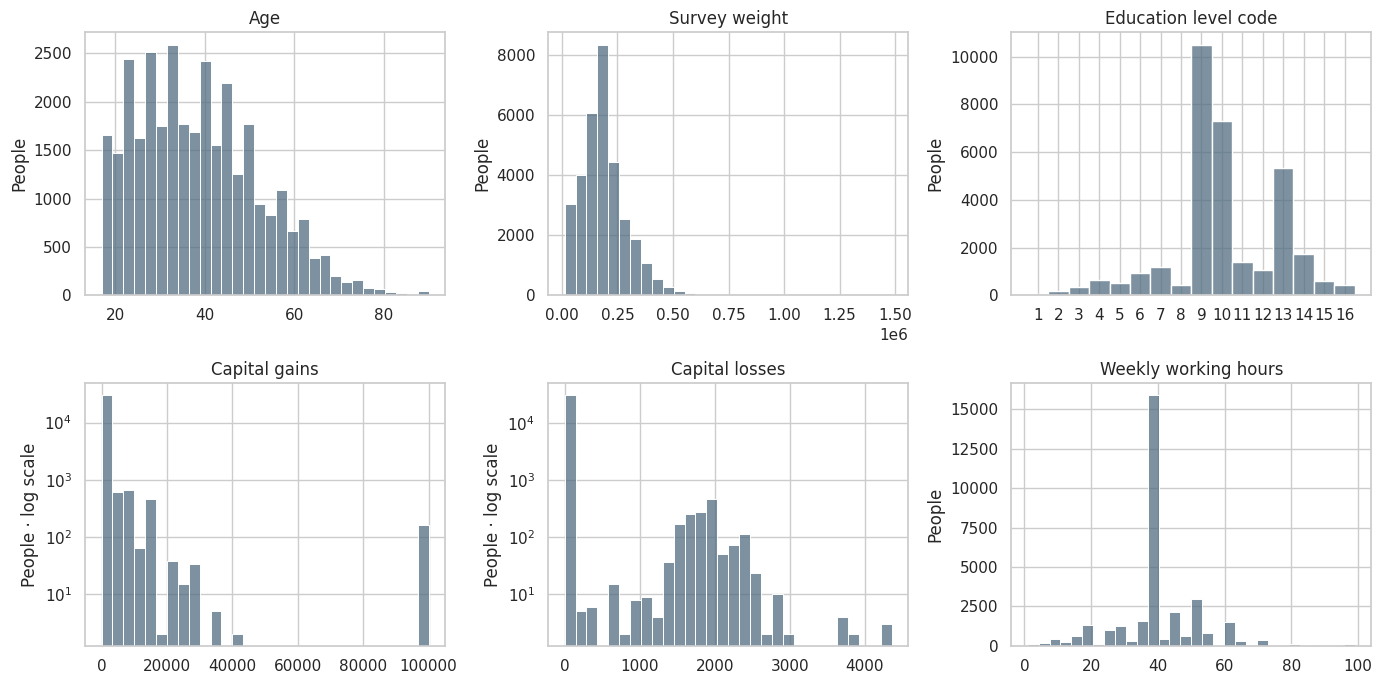

In [11]:
titles = {"age": "Age", "fnlwgt": "Survey weight", "education-num": "Education level code", "capital-gain": "Capital gains", "capital-loss": "Capital losses", "hours-per-week": "Weekly working hours"}
axes = plt.subplots(2, 3, figsize=(14, 7))[1]
for column, ax in zip(numerical, axes.flat):
    sns.histplot(data=train_df, x=column, bins=30, discrete=column == "education-num", ax=ax, color="#526D82")
    ax.set(title=titles[column], xlabel="", ylabel="People")
    if column == "education-num":
        ax.set_xticks(range(1, 17))
    if column in ["capital-gain", "capital-loss"]:
        ax.set_yscale("log")
        ax.set_ylabel("People · log scale")
plt.tight_layout()
plt.show()

In [12]:
capital_zeros = train_df[["capital-gain", "capital-loss"]].eq(0).mean().mul(100)
display(capital_zeros.to_frame("Zero values %").round(2))

,Zero values %
capital-gain,91.67
capital-loss,95.33


- **Hours:** peak around 40.
- **Capital:** mostly zero, with a long positive tail.
- **Charts:** logarithmic counts; recorded values unchanged.

### Categorical distributions

Change `column` to inspect another feature.

In [13]:
categorical = train_df.select_dtypes(exclude="number").columns.drop("income").tolist()
category_rows = []

for column in categorical:
    counts = train_df[column].value_counts()
    category_rows.append({
        "Column": column,
        "Categories number": len(counts),
        "Most common": counts.index[0],
        "Most common count": counts.iloc[0],
        "Most common share %": 100 * counts.iloc[0] / len(train_df),
        "Least common": counts.index[-1],
        "Least common count": counts.iloc[-1],
        "Least common share %": 100 * counts.iloc[-1] / len(train_df)
    })

display(pd.DataFrame(category_rows).set_index("Column").round(2))

,Categories number,Most common,Most common count,Most common share %,Least common,Least common count,Least common share %
Column,,,,,,,
workclass,8,Private,22696,69.70,Never-worked,7,0.02
education,16,HS-grad,10501,32.25,Preschool,51,0.16
marital-status,7,Married-civ-spouse,14976,45.99,Married-AF-spouse,23,0.07
occupation,14,Prof-specialty,4140,12.71,Armed-Forces,9,0.03
relationship,6,Husband,13193,40.52,Other-relative,981,3.01
race,5,White,27816,85.43,Other,271,0.83
sex,2,Male,21790,66.92,Female,10771,33.08
native-country,41,United-States,29170,89.59,Holand-Netherlands,1,0.00


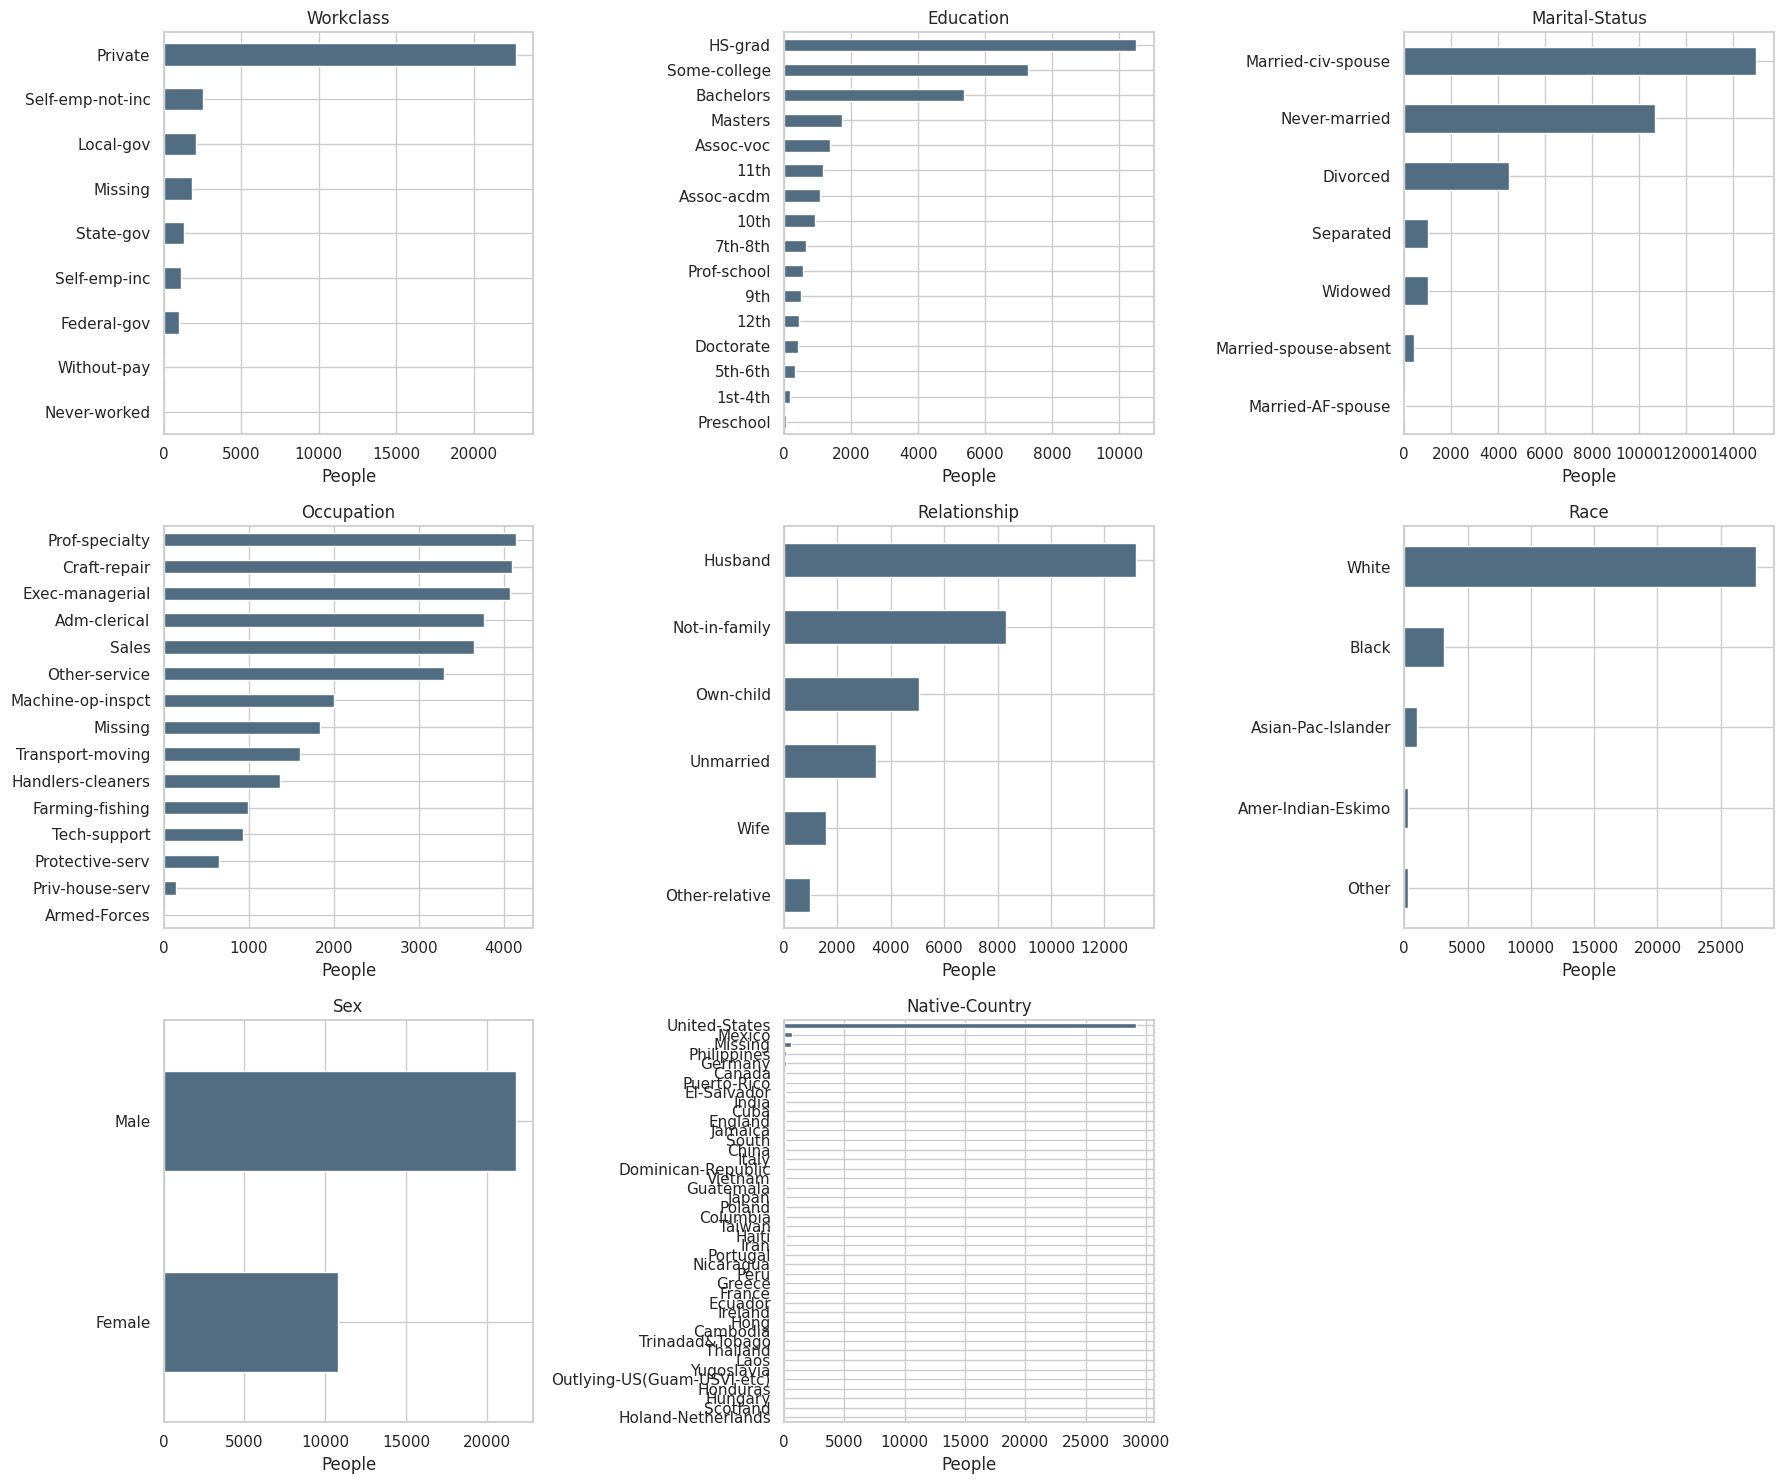

In [14]:
import math

n_cols = 3
n_rows = math.ceil(len(categorical) / n_cols)

axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)[1]

axes = axes.flatten()

for column, ax in zip(categorical, axes):
    counts = train_df[column].fillna("Missing").value_counts().sort_values()

    counts.plot.barh(ax=ax, color="#526D82")

    ax.set(
        title=column.title(),
        xlabel="People",
        ylabel=""
    )

for ax in axes[len(categorical):]:
    ax.remove()

plt.tight_layout()
plt.show()

- **Common:** private employment, high-school education, US origin.
- **Rare:** some categories have few records.
- **Missing:** a chart label only; no values filled yet.

### Missing values

In [15]:
missing = pd.DataFrame({"Missing": train_df.isna().sum(), "Share %": 100 * train_df.isna().mean()})
display(missing.loc[missing["Missing"].gt(0)].sort_values("Missing", ascending=False).round(2))

,Missing,Share %
occupation,1843,5.66
workclass,1836,5.64
native-country,583,1.79


**Missing values:** categorical only.

### Repeated rows and consistency

In [16]:
checks = pd.Series({
    "Repeated training rows": train_df.duplicated().sum(),
    "Age below 17": train_df["age"].lt(17).sum(),
    "Nonpositive working hours": train_df["hours-per-week"].le(0).sum(),
    "Negative capital values": train_df[["capital-gain", "capital-loss"]].lt(0).sum().sum(),
    "Nonpositive survey weights": train_df["fnlwgt"].le(0).sum(),
    "Education codes outside 1–16": (~train_df["education-num"].between(1, 16)).sum(),
    "Missing income labels": train_df["income"].isna().sum(),
    "Unexpected income labels": (~train_df["income"].isin(["<=50K", ">50K"])).sum(),
    "Education labels with multiple codes": train_df.groupby("education")["education-num"].nunique().gt(1).sum(),
    "Education codes with multiple labels": train_df.groupby("education-num")["education"].nunique().gt(1).sum()
}, name="Cases")
display(checks.to_frame())
feature_columns = columns[:-1]
overlap = test_df.merge(train_df[feature_columns].drop_duplicates(), on=feature_columns, how="inner")
print("Test records with features matching training records:", len(overlap))

,Cases
Repeated training rows,24
Age below 17,0
Nonpositive working hours,0
Negative capital values,0
Nonpositive survey weights,0
Education codes outside 1–16,0
Missing income labels,0
Unexpected income labels,0
Education labels with multiple codes,0
Education codes with multiple labels,0


Test records with features matching training records: 26


- Numerical and income-label checks pass.
- Education labels and codes correspond one-to-one.
- Repeated records and matches across sets are present.

### Unusual numerical values

Boxplots and the interquartile rule flag values for review. A flag does not prove an error.

,Q1,Q3,IQR,Lower limit,Upper limit,Flagged records
Column,,,,,,
age,28.0,48.0,20.0,-2.0,78.0,143
fnlwgt,117827.0,237051.0,119224.0,-61009.0,415887.0,992
education-num,9.0,12.0,3.0,4.5,16.5,1198
capital-gain,0.0,0.0,0.0,0.0,0.0,2712
capital-loss,0.0,0.0,0.0,0.0,0.0,1519
hours-per-week,40.0,45.0,5.0,32.5,52.5,9008


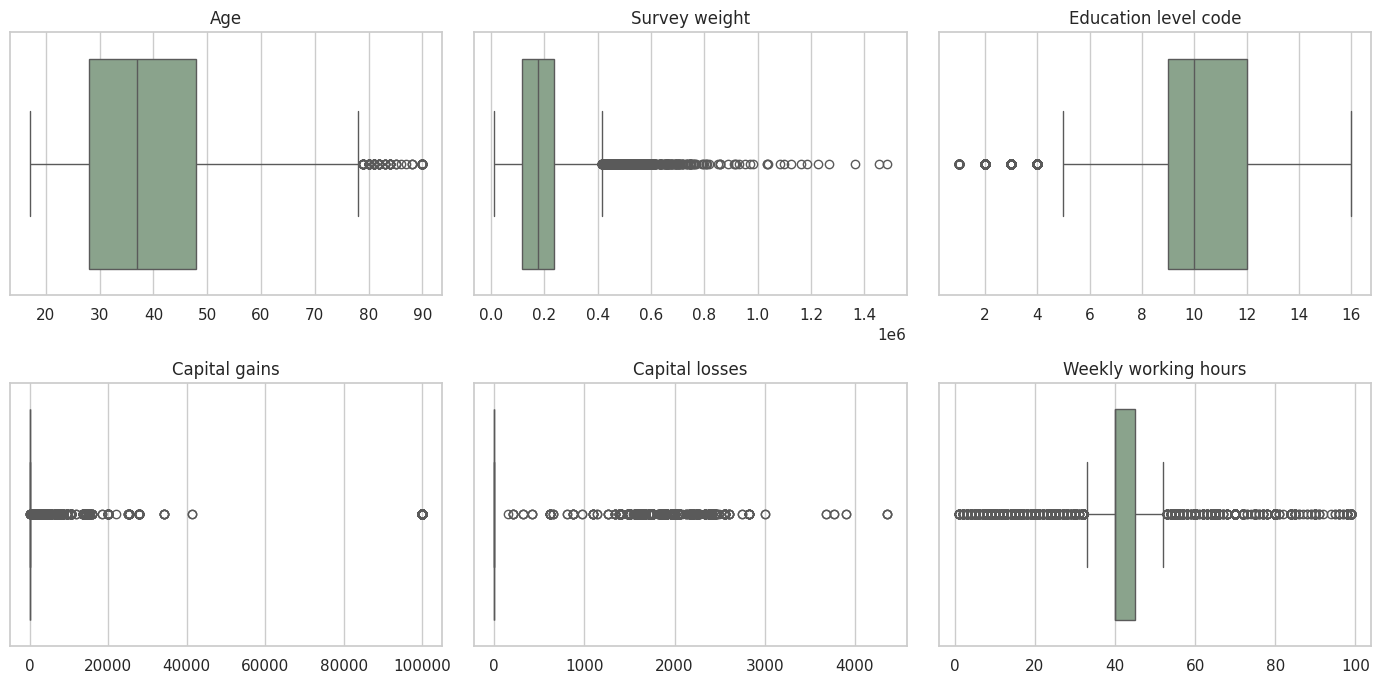

In [17]:
outlier_rows = []

for column in numerical:
    q1 = train_df[column].quantile(.25)
    q3 = train_df[column].quantile(.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = ~train_df[column].between(lower, upper)

    outlier_rows.append({
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower limit": lower,
        "Upper limit": upper,
        "Flagged records": flagged.sum()
    })

display(
    pd.DataFrame(outlier_rows).set_index("Column")
)

axes = plt.subplots(
    2,
    3,
    figsize=(14, 7)
)[1]

for column, ax in zip(numerical, axes.flatten()):
    sns.boxplot(
        data=train_df,
        x=column,
        ax=ax,
        color="#86A789"
    )
    ax.set(
        title=titles.get(column, column),
        xlabel=""
    )

plt.tight_layout()
plt.show()

- Older ages, part-time work and long working weeks can be valid.
- Capital quartiles are both zero: the rule would flag every positive amount.

### Relationships with income

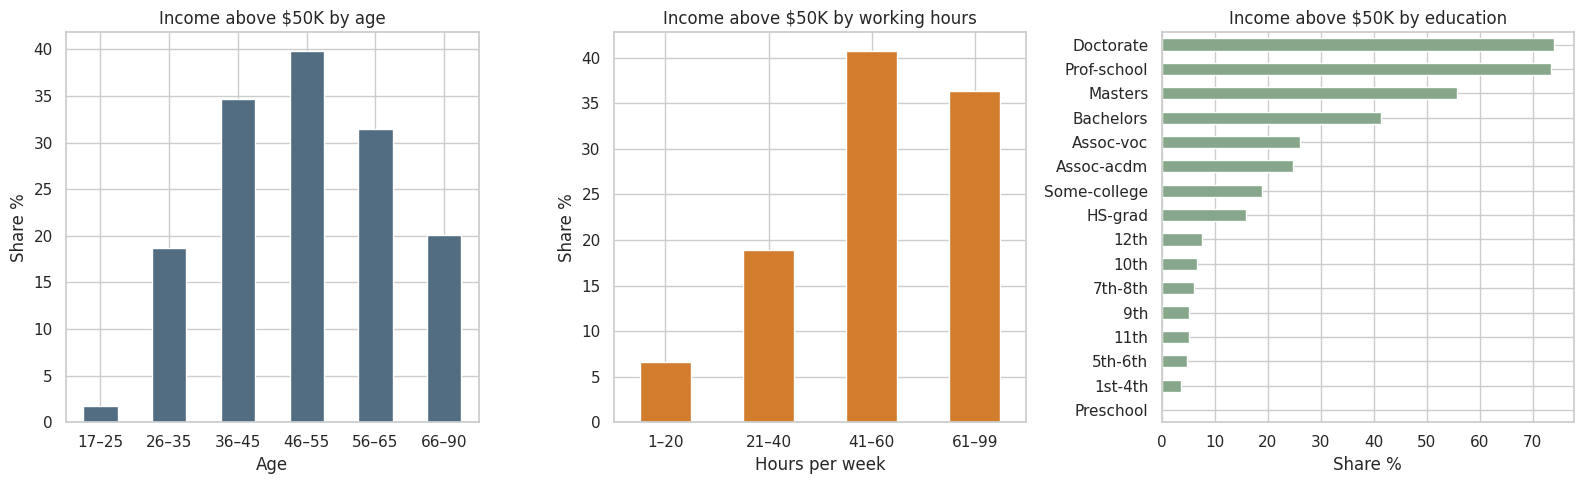

In [18]:
high_income = train_df["income"].eq(">50K")
age_groups = pd.cut(train_df["age"], [16, 25, 35, 45, 55, 65, 90], labels=["17–25", "26–35", "36–45", "46–55", "56–65", "66–90"])
hour_groups = pd.cut(train_df["hours-per-week"], [0, 20, 40, 60, 99], labels=["1–20", "21–40", "41–60", "61–99"])
age_rates = high_income.groupby(age_groups, observed=True).mean().mul(100)
hour_rates = high_income.groupby(hour_groups, observed=True).mean().mul(100)
education_rates = high_income.groupby(train_df["education"]).mean().mul(100)

axes = plt.subplots(1, 3, figsize=(16, 5))[1]
age_rates.plot.bar(ax=axes[0], color="#526D82", rot=0)
hour_rates.plot.bar(ax=axes[1], color="#D27D2D", rot=0)
education_rates.sort_values().plot.barh(ax=axes[2], color="#86A789")
axes[0].set(title="Income above $50K by age", xlabel="Age", ylabel="Share %")
axes[1].set(title="Income above $50K by working hours", xlabel="Hours per week", ylabel="Share %")
axes[2].set(title="Income above $50K by education", xlabel="Share %", ylabel="")
plt.tight_layout()
plt.show()

| Variable | Observed income pattern |
|---|---|
| Education | Higher levels have higher-income shares |
| Working hours | Above 40 hours has a higher-income share |
| Age | Share peaks in middle age |

### Numerical relationships

Spearman correlation compares ranks, including ordered education codes.

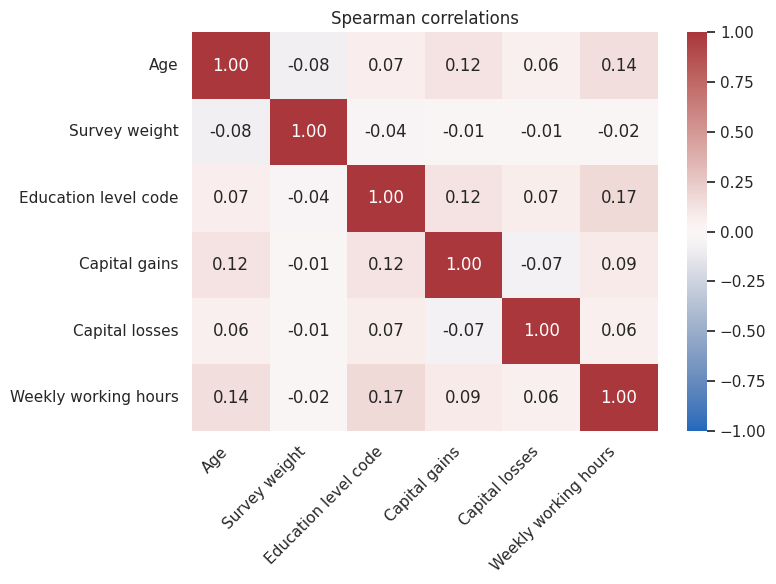

In [19]:
correlation = train_df[numerical].corr(method="spearman")
ax = plt.subplots(figsize=(8, 6))[1]
sns.heatmap(correlation, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, cmap="vlag", ax=ax)
ax.set(title="Spearman correlations", xlabel="", ylabel="")
ax.set_xticklabels([titles[column] for column in numerical], rotation=45, ha="right")
ax.set_yticklabels([titles[column] for column in numerical], rotation=0)
plt.tight_layout()
plt.show()

**Weak pairwise correlations:** combinations of variables may still matter.

### Preparation decisions

| Finding | Action | Reason |
|---|---|---|
| Missing categories | Fill with `Unknown` | Keep records and missingness visible |
| Repeated and cross-set matches | Retain; report cross-set overlap | No person identifier |
| Extreme ages and hours | Retain | Plausible values; no proven error |
| Capital's long positive tail | Test `log1p`; retain log capital gain | Compress large values; preserve zero |
| Duplicate education information | Use `education-num` | Avoid redundant inputs |
| `fnlwgt` | Keep in data; exclude from models | Survey weight, not a personal attribute |
| Rare categories | Retain; accept unseen categories | Preserve records and allow new categories |
| Race and sex | Keep for audit; exclude from models | Retain audit fields; other features can remain proxies |
| Unequal income classes | Report precision, recall and F1 alongside accuracy | Assess the smaller class |

## 4. Data Preparation
### 4.1 Handling Missing Values
#### 4.1.1 Identification of Missing Values

| Variable | Missing | Share |
|---|---:|---:|
| `occupation` | 1,843 | 5.66% |
| `workclass` | 1,836 | 5.64% |
| `native-country` | 583 | 1.79% |

Missing values occur only in these categorical columns; numeric features and `income` are complete. Dropping incomplete rows from the 32,561-person training set would lose potentially useful records, including information in `workclass` and `occupation` for predicting income above $50K.

#### 4.1.2 Visualisation des valeurs manquantes

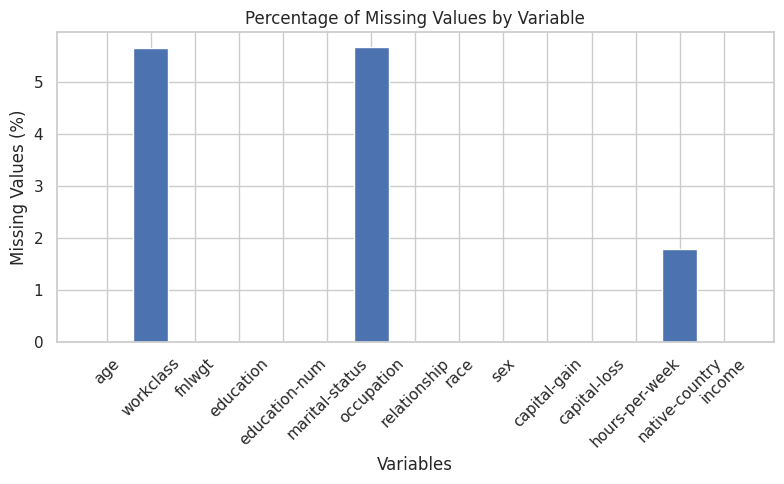

In [20]:
missing_plot = missing.copy()

missing_plot['Percentage'] = (missing_plot['Missing'] / len(train_df)) * 100

plt.figure(figsize=(8, 5))

plt.bar(
    missing_plot.index,
    missing_plot['Percentage']
)

plt.xlabel('Variables')
plt.ylabel('Missing Values (%)')
plt.title('Percentage of Missing Values by Variable')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 4.1.3 Choosing the Imputation Strategy

| Variable | Missing | Treatment |
|---|---:|---|
| `workclass` | 5.64% | `Unknown` |
| `occupation` | 5.66% | `Unknown` |
| `native-country` | 1.79% | `Unknown` |

Using the mode would assume that every missing entry belongs to the most common class (for example, `Private`) and inflate that class. `Unknown` retains the fact that the original category was unavailable without making that assumption.

#### 4.1.4 Applying the Treatment

In [21]:
categorical_missing_cols = [
    'workclass',
    'occupation',
    'native-country'
]

train_df[categorical_missing_cols] = train_df[categorical_missing_cols].fillna('Unknown')
train_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### 4.2 Handling Outlier
#### 4.2.1 Outlier Detection Using the IQR Method

The interquartile rule flags values outside `Q1 − 1.5·IQR` and `Q3 + 1.5·IQR`. A flag means "far from the bulk of the data", not "wrong". Each flagged group is therefore checked against what the variable means.

In [22]:
numerical = train_df.select_dtypes(include="number").columns.tolist()

review = []
for column in numerical:
    q1, q3 = train_df[column].quantile([.25, .75])
    iqr = q3 - q1
    flagged = ~train_df[column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    review.append({
        "Column": column,
        "Flagged": flagged.sum(),
        "Flagged %": 100 * flagged.mean(),
        "Median": train_df[column].median(),
        "Minimum": train_df[column].min(),
        "Maximum": train_df[column].max(),
    })
display(pd.DataFrame(review).set_index("Column").round(2))

,Flagged,Flagged %,Median,Minimum,Maximum
Column,,,,,
age,143,0.44,37.0,17,90
fnlwgt,992,3.05,178356.0,12285,1484705
education-num,1198,3.68,10.0,1,16
capital-gain,2712,8.33,0.0,0,99999
capital-loss,1519,4.67,0.0,0,4356
hours-per-week,9008,27.66,40.0,1,99


#### 4.2.2 Checking the Extreme Values

The rule is unreliable for `capital-gain` and `capital-loss` (both quartiles are 0, so every positive amount is flagged) and for `hours-per-week` (almost half of people work exactly 40 hours, so the IQR is only 5 hours wide). The extreme values themselves are inspected directly, together with their income rate.

#### 4.2.3 Outlier Treatment Decision

| Variable | IQR flags | Why flagged | Action |
|---|---:|---|---|
| `age` | 143 | Ages 79–90 | Keep |
| `fnlwgt` | 992 | Large sampling weights | Keep |
| `education-num` | 1,198 | Low levels (1–4) | Keep |
| `capital-gain` | 2,712 | Every positive amount | Keep |
| `capital-loss` | 1,519 | Every positive amount | Keep |
| `hours-per-week` | 9,008 | Away from the 40-hour spike | Keep |

<span style="color:#b91c1c">→ Keep all flagged records: none is shown to be invalid, and deletion could lose informative minority groups.</span>

### 4.3 Numerical Variables and Their Distributions
#### 4.3.1 Distribution Overview

In [23]:
profile = pd.DataFrame({
    "Mean": train_df[numerical].mean(),
    "Std": train_df[numerical].std(),
    "Min": train_df[numerical].min(),
    "Max": train_df[numerical].max(),
    "Skewness": train_df[numerical].skew(),
    "Zeros %": 100 * train_df[numerical].eq(0).mean(),
})
display(profile.round(2))

,Mean,Std,Min,Max,Skewness,Zeros %
age,38.58,13.64,17,90,0.56,0.00
fnlwgt,189778.37,105549.98,12285,1484705,1.45,0.00
education-num,10.08,2.57,1,16,-0.31,0.00
capital-gain,1077.65,7385.29,0,99999,11.95,91.67
capital-loss,87.30,402.96,0,4356,4.59,95.33
hours-per-week,40.44,12.35,1,99,0.23,0.00


<span style="color:#b91c1c">→ Capital gain needs a closer look; the other numeric features do not need a general transformation here.</span>

| Variable | Skewness | Reading | Decision |
|---|---:|---|---|
| `age` | 0.56 | Mild right tail | Keep |
| `education-num` | −0.31 | Roughly symmetric ordered code | Keep |
| `hours-per-week` | 0.23 | Spike near 40 | Keep |
| `fnlwgt` | 1.45 | Survey weight | Exclude from models |
| `capital-gain` | 11.95 | 91.7% zeros, extreme tail | Examine `log1p` |
| `capital-loss` | 4.59 | 95.3% zeros | Examine positive values |

Scales also differ: standard deviation is about 105,000 for `fnlwgt`, 7,400 for `capital-gain`, and 2.6 for `education-num`.

#### 4.3.2 Transformation of Capital Gains and Losses

`log1p(x) = log(1 + x)` compresses large amounts while keeping 0 as 0 (a plain `log` fails on zero). Section 3 planned it for both capital columns, but a transformation should be tested before it is applied. The skewness is reported over all people and over the people with a positive amount, where the transformation actually acts. The log version is computed for both columns, to compare, but only the gain version is kept.

,All people: raw,All people: log1p,Positive only: raw,Positive only: log1p
Column,,,,
capital-gain,11.95,3.10,3.41,0.56
capital-loss,4.59,4.31,0.37,-3.70


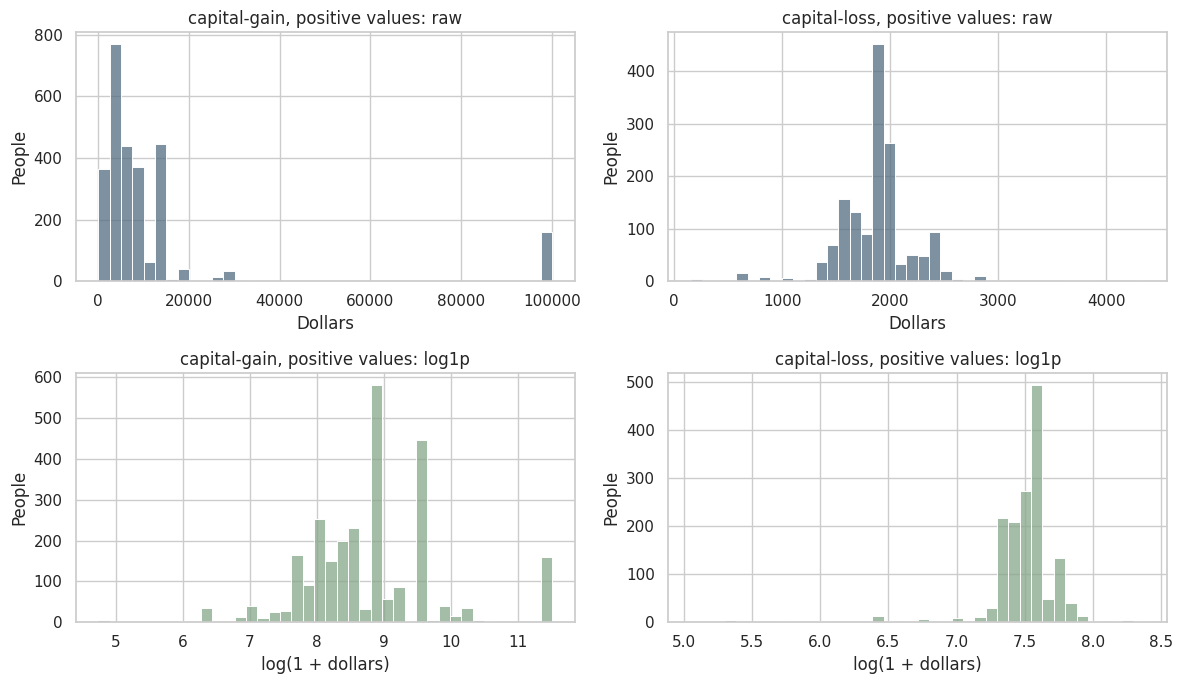

In [24]:
for column in ["capital-gain", "capital-loss"]:
    train_df[f"{column}_log"] = np.log1p(train_df[column])

rows = []
for column in ["capital-gain", "capital-loss"]:
    positive = train_df.loc[train_df[column] > 0, column]
    rows.append({
        "Column": column,
        "All people: raw": train_df[column].skew(),
        "All people: log1p": train_df[f"{column}_log"].skew(),
        "Positive only: raw": positive.skew(),
        "Positive only: log1p": np.log1p(positive).skew(),
    })
display(pd.DataFrame(rows).set_index("Column").round(2))

axes = plt.subplots(2, 2, figsize=(12, 7))[1]
for col_idx, column in enumerate(["capital-gain", "capital-loss"]):
    positive = train_df.loc[train_df[column] > 0, column]
    sns.histplot(positive, bins=40, ax=axes[0, col_idx], color="#526D82")
    axes[0, col_idx].set(title=f"{column}, positive values: raw", xlabel="Dollars", ylabel="People")
    sns.histplot(np.log1p(positive), bins=40, ax=axes[1, col_idx], color="#86A789")
    axes[1, col_idx].set(title=f"{column}, positive values: log1p", xlabel="log(1 + dollars)", ylabel="People")
plt.tight_layout()
plt.show()

train_df = train_df.drop(columns=["capital-loss_log", "capital-gain"])

<span style="color:#b91c1c">→ Keep the log of capital gain, but retain capital loss in dollars.</span>

- Among positive gains, `log1p` reduces skewness from 3.41 to 0.56 and compresses the 114–99,999 dollar range.
- Among positive losses, most amounts are about 1,700–2,000 dollars and skewness changes from 0.37 to −3.70; the log creates a left tail. The overall 4.59 skew comes mainly from the 95% zeros, so the Section 3 plan is refined.

#### 4.3.3 Scaling Decision

Scaling is applied separately for K-Means and KNN. The KNN scaler is fitted on training data and then applied to the test data.

### 4.4 Feature Engineering

The retained derived feature is `capital-gain_log`, created in Section 4.3. It compresses large gains and keeps zero as zero. The original gain column is replaced by this representation; age and weekly working hours remain numerical inputs.

<span style="color:#1d4ed8">→ Preparation follows the supplied run: log capital gain and seven categorical variables give 85 prepared features.</span>

<span style="color:#b91c1c">→ Log capital gain is the derived input retained after testing the numerical transformations.</span>

### 4.5 Categorical Variables
#### 4.5.1 Identification of Categorical Variables

The nominal variables are `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex` and `native-country`. The target `income` has two classes: `<=50K` and `>50K`.

Before choosing an encoding, the number of categories and their frequencies are examined, since variables with many rare categories need different handling than binary ones.

In [25]:
categorical = train_df.select_dtypes(exclude="number").columns.drop("income").tolist()
category_rows = []

for column in categorical:
    shares = 100 * train_df[column].value_counts(normalize=True)
    category_rows.append({
        "Column": column,
        "Categories number": len(shares),
        "Most common": shares.index[0],
        "Most common share %": shares.iloc[0],
        "Least common": shares.index[-1],
        "Least common share %": shares.iloc[-1],
        "Categories below 1%": (shares < 1).sum(),
    })

display(pd.DataFrame(category_rows).set_index("Column").round(2))

,Categories number,Most common,Most common share %,Least common,Least common share %,Categories below 1%
Column,,,,,,
workclass,9,Private,69.70,Never-worked,0.02,2
education,16,HS-grad,32.25,Preschool,0.16,2
marital-status,7,Married-civ-spouse,45.99,Married-AF-spouse,0.07,1
occupation,15,Prof-specialty,12.71,Armed-Forces,0.03,2
relationship,6,Husband,40.52,Other-relative,3.01,0
race,5,White,85.43,Other,0.83,2
sex,2,Male,66.92,Female,33.08,0
native-country,42,United-States,89.59,Holand-Netherlands,0.00,39


#### 4.5.2 Cardinality Analysis and Label Cleaning

`native-country` has the highest cardinality (**42 categories** including `Unknown`), and `United-States` covers about 90% of people. 39 of the 42 categories are below 1% of the data. One-hot encoding creates one column per category, which stays manageable here (a few dozen columns), and no category is removed for being rare: the country of origin may still carry information, and test features are aligned to the training columns with `reindex(..., fill_value=0)`. This also handles absent or unseen test categories without changing the training layout.

The country labels are cleaned before encoding:

- **Spelling** in the source files: `Holand-Netherlands`, `Trinadad&Tobago`, `Columbia` (Colombia) and `Hong` (Hong-Kong). `South` is ambiguous (probably South Korea) and is left unchanged rather than guessed.

In [26]:
country_typos = {"Holand-Netherlands": "Netherlands", "Trinadad&Tobago": "Trinidad&Tobago",
                 "Columbia": "Colombia", "Hong": "Hong-Kong"}
train_df["native-country"] = train_df["native-country"].replace(country_typos)

text_columns = categorical.copy()
whitespace_problems = {c: int((train_df[c] != train_df[c].str.strip()).sum()) for c in text_columns}
print("Labels with leading/trailing spaces:", whitespace_problems)
print("Countries now:", train_df["native-country"].nunique())

Labels with leading/trailing spaces: {'workclass': 0, 'education': 0, 'marital-status': 0, 'occupation': 0, 'relationship': 0, 'race': 0, 'sex': 0, 'native-country': 0}
Countries now: 42


#### 4.5.3 Education Representation

`education` and `education-num` describe the same information (the check in Section 3 confirmed a one-to-one mapping: for example `Bachelors` is always 13). Keeping both would feed the same signal to a model twice. `education-num` is kept because it preserves the order of the levels, and the 16 text categories are dropped, which avoids 15 extra indicator columns.

In [27]:
train_df = train_df.drop(columns=["education"])

#### 4.5.4 One-Hot Encoding Strategy

The remaining variables are nominal: their categories have no natural order. Encoding them as `Private = 1`, `State-gov = 2`, `Federal-gov = 3` would suggest an ordering that does not exist. **One-hot encoding** creates one binary column per category instead.

| sex    | sex_Female | sex_Male |
| ------ | ---------: | -------: |
| Female |          1 |        0 |
| Male   |          0 |        1 |

One category per variable is dropped (`drop_first=True`) because it is implied by the others; this removes perfect redundancy between the columns, which matters for linear models.

#### 4.5.5 Applying One-Hot Encoding

In [28]:
categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

#### 4.5.6 Verify the Transformation

In [29]:
train_df.head()

,age,fnlwgt,education-num,capital-loss,hours-per-week,income,capital-gain_log,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinidad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,0,40,<=50K,7.684784,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,13,<=50K,0.000000,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,40,<=50K,0.000000,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,53,234721,7,0,40,<=50K,0.000000,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28,338409,13,0,40,<=50K,0.000000,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [30]:
print("Number of columns after encoding:", train_df.shape[1])

Number of columns after encoding: 86


In [31]:
train_df.dtypes.value_counts()

int64      84
object      1
float64     1
Name: count, dtype: int64

### 4.6 Target Variable

`income` is the label the classification models predict. It is converted to a binary variable: `<=50K` → `0` and `>50K` → `1`. It is kept apart from the input features `X` to avoid leakage.

The test file writes its labels with a trailing dot (`<=50K.`), which would be read as two extra classes. The dot is removed before encoding, and the result is verified.

In [32]:
print("Test labels before:", sorted(test_df["income"].unique()))
test_df["income"] = test_df["income"].str.rstrip(".")
print("Test labels after: ", sorted(test_df["income"].unique()))

X = train_df.drop(columns=["income"])
y = train_df["income"].map({"<=50K": 0, ">50K": 1})

balance = pd.DataFrame({
    "Training": y.value_counts(),
    "Test": test_df["income"].map({"<=50K": 0, ">50K": 1}).value_counts(),
})
balance.index = ["<=50K (0)", ">50K (1)"]
display(balance.assign(**{"Training %": 100 * balance["Training"] / balance["Training"].sum(),
                          "Test %": 100 * balance["Test"] / balance["Test"].sum()}).round(1))

Test labels before: ['<=50K.', '>50K.']
Test labels after:  ['<=50K', '>50K']


,Training,Test,Training %,Test %
<=50K (0),24720,12435,75.9,76.4
>50K (1),7841,3846,24.1,23.6


### 4.7 Other Data Quality Issues

In [33]:
duplicates = train_df.duplicated().sum()
print(f"Repeated training rows: {duplicates} ({100 * duplicates / len(train_df):.2f}% of the data)")

Repeated training rows: 24 (0.07% of the data)


### 4.8 Applying the Same Preparation to the Test Set
Every training step is repeated on the test set with **rules learned from the training data only** (here: the column layout). Writing the steps as one function removes the risk of treating the two sets differently, and the function is validated by rebuilding the training matrix from the raw file and checking it is identical to the one built step by step above.

Two details matter for the test set: its own `get_dummies` call must not decide which category is dropped (the training columns are used as the reference), and categories absent from the test set must still produce a column (filled with 0).

<span style="color:#1d4ed8">→ The same preparation rules rebuild training data, align test columns, and report unseen categories and overlaps.</span>

In [34]:
missing_cols = ["workclass", "occupation", "native-country"]
def prepare(df, reference_columns=None):
    """Replay all of Section 4 on a raw dataframe. Returns (X, y)."""
    df = df.copy()
    df[missing_cols] = df[missing_cols].fillna("Unknown")
    df["native-country"] = df["native-country"].replace(country_typos)
    df["capital-gain_log"] = np.log1p(df["capital-gain"])
    df = df.drop(columns=["education", "capital-gain"])
    target = df.pop("income").str.rstrip(".").map({"<=50K": 0, ">50K": 1})
    if reference_columns is None:
        features = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)
    else:
        features = pd.get_dummies(df, columns=categorical_features, dtype=int).reindex(columns=reference_columns, fill_value=0)
    return features, target

read_args = dict(header=None, names=columns, skipinitialspace=True, na_values="?")
raw_train = pd.read_csv(folder + "adult.data", **read_args)
raw_test = pd.read_csv(folder + "adult.test", skiprows=1, **read_args)

X_check, y_check = prepare(raw_train)
pd.testing.assert_frame_equal(X_check[X.columns], X, check_dtype=False)
assert y_check.equals(y)
print("Function check passed: identical to the step-by-step training matrix")

X_test, y_test = prepare(raw_test, reference_columns=X.columns)
print("Training matrix:", X.shape, "| Test matrix:", X_test.shape)
print("Same columns, same order:", list(X_test.columns) == list(X.columns))
print("Missing values in test matrix:", int(X_test.isna().sum().sum()))

unseen = {c: sorted(set(raw_test[c].dropna()) - set(raw_train[c].dropna())) for c in text_columns}
print("Unseen test categories:", {c: v for c, v in unseen.items() if v} or "none")

overlap = X_test.merge(X.drop_duplicates(), how="inner")
print("Test rows identical to a training row:", len(overlap))

Function check passed: identical to the step-by-step training matrix
Training matrix: (32561, 85) | Test matrix: (16281, 85)
Same columns, same order: True
Missing values in test matrix: 0
Unseen test categories: none
Test rows identical to a training row: 26


<span style="color:#b91c1c">→ The preparation function reproduces the training matrix and gives the test set the same columns in the same order.</span>

### 4.9 Final Datasets and Summary

In [35]:
audit_cols = [c for c in X.columns if c.startswith(("race_", "sex_"))]
model_features = [c for c in X.columns if c not in audit_cols + ["fnlwgt"]]

dataset_summary = pd.DataFrame({
    "Rows": [len(X), len(X_test)],
    "Columns": [X.shape[1], X_test.shape[1]],
    "Missing values": [int(X.isna().sum().sum()), int(X_test.isna().sum().sum())],
    "Income >50K %": [100 * y.mean(), 100 * y_test.mean()],
}, index=["Training", "Test"])
display(dataset_summary.round(1))
print(f"Model features: {len(model_features)} | Audit columns (race, sex): {len(audit_cols)} | Excluded survey weight: fnlwgt")

,Rows,Columns,Missing values,Income >50K %
Training,32561,85,0,24.1
Test,16281,85,0,23.6


Model features: 79 | Audit columns (race, sex): 5 | Excluded survey weight: fnlwgt


## 5. Segmentation

### 5.1 Problem Definition & Feature Selection

**Objective:** Group individuals into clusters based on similar characteristics related to work and education, without using income information.

**Selected Features:**
- `age`: Age in years
- `education-num`: Numerical representation of education level (1=Preschool to 16=Doctorate)
- `hours-per-week`: Weekly working hours

**Why these features?**
- These three features capture key socio-professional dimensions: life stage (age), educational attainment (education-num), and work intensity (hours-per-week).
- As stated in the Business Understanding, the goal is to discover natural groupings based on these characteristics and then explore how income varies across the resulting segments.

**Role of income:**
- Income is **not used to create the clusters** because clustering is unsupervised learning performed without the target variable.
- However, income **will be analyzed after clustering** to understand the economic characteristics of the resulting groups and discover associations between cluster profiles and income levels.

### 5.2 Data Preparation for Clustering

<span style="color:#1d4ed8">→ The clustering check uses age, education level and weekly hours, then reports missingness and summaries.</span>

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clustering_features = ['age', 'education-num', 'hours-per-week']

X_cluster = train_df[clustering_features].copy()

print(f"Clustering dataset: {X_cluster.shape[0]} rows, {X_cluster.shape[1]} features")
print(f"\nFeatures: {clustering_features}")

print(f"\nMissing values:")
display(X_cluster.isnull().sum().to_frame("Missing Count"))

display(X_cluster.describe().round(2))

Clustering dataset: 32561 rows, 3 features

Features: ['age', 'education-num', 'hours-per-week']

Missing values:


,Missing Count
age,0
education-num,0
hours-per-week,0


,age,education-num,hours-per-week
count,32561.00,32561.00,32561.00
mean,38.58,10.08,40.44
std,13.64,2.57,12.35
min,17.00,1.00,1.00
25%,28.00,9.00,40.00
50%,37.00,10.00,40.00
75%,48.00,12.00,45.00
max,90.00,16.00,99.00


<span style="color:#b91c1c">→ The three clustering features are complete, but their ranges differ: age 17–90, education code 1–16, and hours 1–99.</span>

Higher `education-num` means more education (1 Preschool, 9 HS-grad, 13 Bachelors, 16 Doctorate); scaling is needed for K-Means.

#### 5.2.1 Feature Scaling

K-Means uses Euclidean distance, so features must be scaled to prevent those with larger ranges from dominating the clustering.

In [37]:
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Before scaling:")
display(pd.DataFrame({
    "Feature": clustering_features,
    "Min": X_cluster.min().values,
    "Max": X_cluster.max().values,
    "Mean": X_cluster.mean().values.round(2),
    "Std": X_cluster.std().values.round(2)
}))

print("\nAfter scaling:")
X_cluster_scaled_df = pd.DataFrame(X_cluster_scaled, columns=clustering_features)
display(pd.DataFrame({
    "Feature": clustering_features,
    "Mean": X_cluster_scaled_df.mean().values.round(10),
    "Std": X_cluster_scaled_df.std().values.round(2)
}))

Before scaling:


,Feature,Min,Max,Mean,Std
0,age,17,90,38.58,13.64
1,education-num,1,16,10.08,2.57
2,hours-per-week,1,99,40.44,12.35



After scaling:


,Feature,Mean,Std
0,age,-0.0,1.0
1,education-num,0.0,1.0
2,hours-per-week,-0.0,1.0


<span style="color:#b91c1c">→ StandardScaler centers the three clustering features near zero and brings their standard deviations near one, making their distance contributions comparable.</span>

### 5.3 Determining the Optimal Number of Clusters

We use two methods to determine the optimal number of clusters:

**Elbow Method:** Plots the within-cluster sum of squares (inertia) for different K values. The "elbow" point indicates where adding more clusters provides diminishing returns.

**Silhouette Score:** Measures how similar each point is to its own cluster compared to other clusters. Higher scores (closer to 1) indicate better-defined clusters.

The optimal number of clusters will be selected based on the results of both methods.

In [38]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

optimization_summary = pd.DataFrame({
    "K": list(k_range),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(optimization_summary.round(3))

,K,Inertia,Silhouette Score
0,2,74195.756,0.250
1,3,56614.545,0.293
2,4,47945.022,0.305
3,5,40588.264,0.321
4,6,34998.651,0.333
5,7,30591.427,0.336
6,8,27262.688,0.335
7,9,25156.202,0.304
8,10,23229.348,0.311


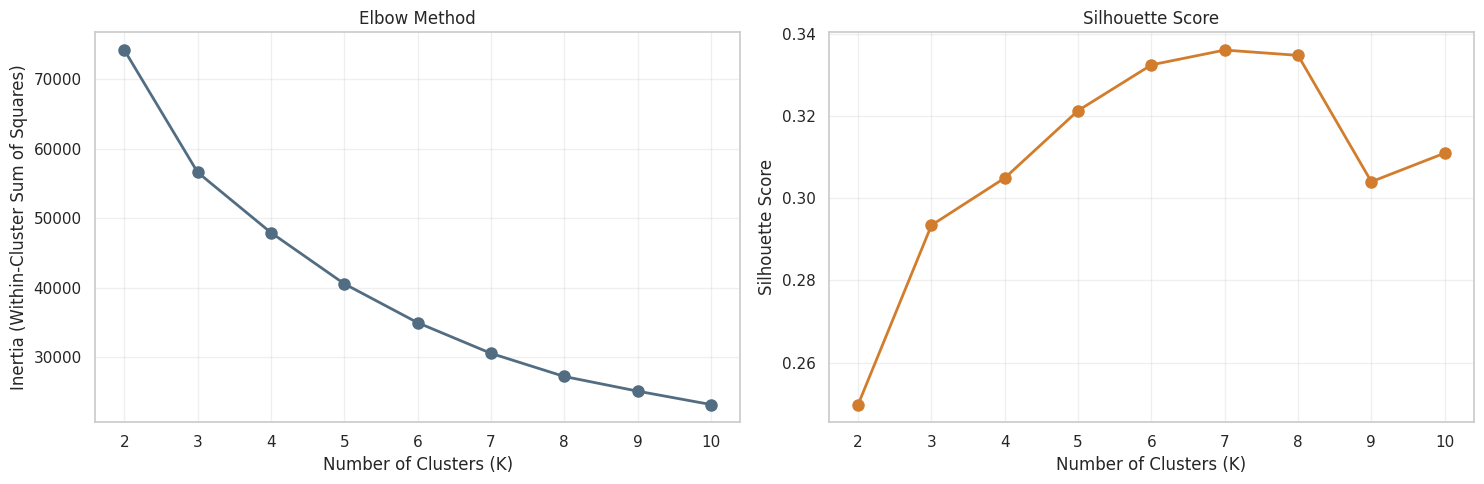

In [39]:
axes = plt.subplots(1, 2, figsize=(15, 5))[1]

axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='#526D82')
axes[0].set(title='Elbow Method', xlabel='Number of Clusters (K)', ylabel='Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#D27D2D')
axes[1].set(title='Silhouette Score', xlabel='Number of Clusters (K)', ylabel='Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<span style="color:#b91c1c">→ K=7 has the highest silhouette score (0.336), with an inertia elbow around K=6–7.</span>

Inertia falls from 74,196 at K=2 to 23,229 at K=10. Silhouette rises from 0.250 at K=2 to 0.336 at K=7, then falls to 0.335 at K=8 and 0.304 at K=9.

#### 5.3.1 Selecting Optimal K

In [40]:
optimal_k = optimization_summary.loc[optimization_summary['Silhouette Score'].idxmax(), 'K']
optimal_k = int(optimal_k)

print(f"Optimal K selected: {optimal_k}")
print(f"Silhouette Score: {optimization_summary.loc[optimization_summary['K']==optimal_k, 'Silhouette Score'].values[0]:.3f}")
print(f"Inertia: {optimization_summary.loc[optimization_summary['K']==optimal_k, 'Inertia'].values[0]:.1f}")

Optimal K selected: 7
Silhouette Score: 0.336
Inertia: 30591.4


<span style="color:#b91c1c">→ Choose K=7: it maximizes silhouette (0.336) and agrees with the elbow around K=6–7.</span>

The score indicates moderate separation, with some overlap.

### 5.4 K-Means Clustering

Train the final K-Means model with the optimal number of clusters.

In [41]:
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

train_df['cluster'] = cluster_labels

print(f"K-Means model trained with K={optimal_k}")
print(f"\nCluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
display(pd.DataFrame({
    "Cluster": cluster_counts.index,
    "Count": cluster_counts.values,
    "Percentage": (100 * cluster_counts.values / len(cluster_labels)).round(1)
}))

K-Means model trained with K=7

Cluster distribution:


,Cluster,Count,Percentage
0,0,9727,29.9
1,1,2599,8.0
2,2,6463,19.8
3,3,3209,9.9
4,4,2149,6.6
5,5,1311,4.0
6,6,7103,21.8


<span style="color:#b91c1c">→ All 32,561 training rows belong to one of seven unequally sized clusters.</span>

Cluster 5 is smallest (1,311; 4.0%) and Cluster 0 largest (9,727; 29.9%). Clusters 0, 6 and 2 together contain 71.5%; the other four each contain less than 10%.

### 5.5 Cluster Visualization

Visualize the clusters in 2D feature space to understand their separation.

<span style="color:#1d4ed8">→ The three plots compare each pair of clustering features; the model itself uses all three.</span>

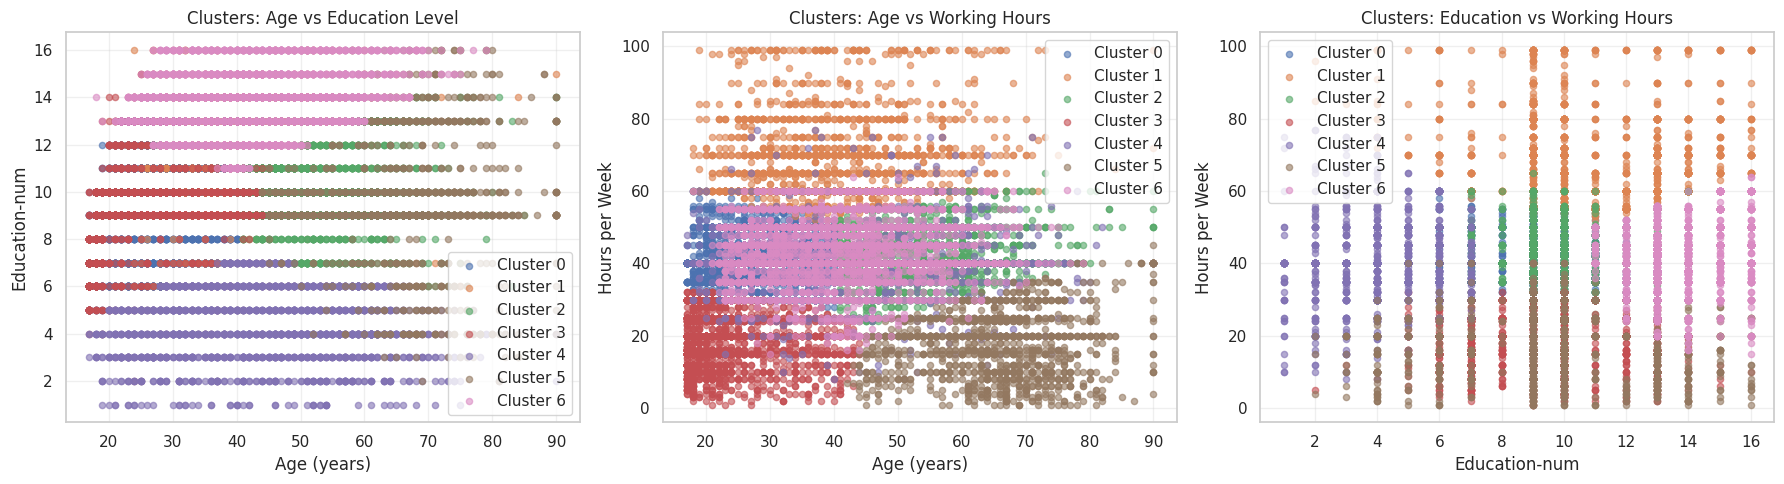

In [42]:
cluster_viz_df = X_cluster.copy()
cluster_viz_df['cluster'] = cluster_labels

axes = plt.subplots(1, 3, figsize=(18, 5))[1]

for cluster_id in range(optimal_k):
    cluster_data = cluster_viz_df[cluster_viz_df['cluster'] == cluster_id]
    axes[0].scatter(cluster_data['age'], cluster_data['education-num'],
                   label=f'Cluster {cluster_id}', alpha=0.6, s=20)
axes[0].set(title='Clusters: Age vs Education Level', xlabel='Age (years)', ylabel='Education-num')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cluster_id in range(optimal_k):
    cluster_data = cluster_viz_df[cluster_viz_df['cluster'] == cluster_id]
    axes[1].scatter(cluster_data['age'], cluster_data['hours-per-week'],
                   label=f'Cluster {cluster_id}', alpha=0.6, s=20)
axes[1].set(title='Clusters: Age vs Working Hours', xlabel='Age (years)', ylabel='Hours per Week')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for cluster_id in range(optimal_k):
    cluster_data = cluster_viz_df[cluster_viz_df['cluster'] == cluster_id]
    axes[2].scatter(cluster_data['education-num'], cluster_data['hours-per-week'],
                   label=f'Cluster {cluster_id}', alpha=0.6, s=20)
axes[2].set(title='Clusters: Education vs Working Hours', xlabel='Education-num', ylabel='Hours per Week')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<span style="color:#b91c1c">→ The two-dimensional views show distinct groups alongside overlap.</span>

High education separates Cluster 6; low education marks Cluster 4. Long hours separate Cluster 1, while Clusters 3 and 5 have low hours. The age–hours and education–hours views reinforce these patterns, though the clustering itself uses all three dimensions.

### 5.6 Cluster Profiling

Analyze the characteristics of each cluster by examining the mean values of the clustering features.

<span style="color:#1d4ed8">→ Profiles report cluster size, averages and within-cluster variation.</span>

In [43]:
cluster_profiles = train_df.groupby('cluster')[clustering_features].agg(['mean', 'std']).round(1)
cluster_sizes = train_df['cluster'].value_counts().sort_index()

profile_summary = pd.DataFrame({
    'Cluster': range(optimal_k),
    'Size': cluster_sizes.values,
    '% of Total': (100 * cluster_sizes.values / len(train_df)).round(1),
    'Avg Age': train_df.groupby('cluster')['age'].mean().values.round(1),
    'Avg Education': train_df.groupby('cluster')['education-num'].mean().values.round(1),
    'Avg Hours/Week': train_df.groupby('cluster')['hours-per-week'].mean().values.round(1)
})

display(profile_summary)

print("\nDetailed cluster statistics:")
display(cluster_profiles)

,Cluster,Size,% of Total,Avg Age,Avg Education,Avg Hours/Week
0,0,9727,29.9,29.3,9.3,41.2
1,1,2599,8.0,40.1,10.8,65.6
2,2,6463,19.8,51.4,9.6,41.2
3,3,3209,9.9,23.3,9.4,20.4
4,4,2149,6.6,44.5,4.5,40.0
5,5,1311,4.0,65.3,9.9,17.9
6,6,7103,21.8,39.3,13.4,42.8



Detailed cluster statistics:


age       education-num      hours-per-week      
         mean   std          mean  std           mean   std
cluster                                                    
0        29.3   6.2           9.3  1.0           41.2   4.5
1        40.1  10.3          10.8  2.2           65.6  10.2
2        51.4   7.8           9.6  1.1           41.2   4.9
3        23.3   6.4           9.4  1.9           20.4   6.9
4        44.5  13.5           4.5  1.5           40.0   8.1
5        65.3  10.0           9.9  2.7           17.9   8.9
6        39.3   9.8          13.4  1.0           42.8   6.3

<span style="color:#b91c1c">→ The seven profiles differ mainly by life stage, education and working hours.</span>

| Cluster | Share | Avg age | Avg education | Avg hours | Profile |
|---|---:|---:|---:|---:|---|
| 0 | 29.9% | 29.3 | 9.3 | 41.2 | Young entry-level workers |
| 1 | 8.0% | 40.1 | 10.8 | 65.6 | Long-hours mid-career workers |
| 2 | 19.8% | 51.4 | 9.6 | 41.2 | Experienced, moderate education |
| 3 | 9.9% | 23.3 | 9.4 | 20.4 | Young part-timers / students |
| 4 | 6.6% | 44.5 | 4.5 | 40.0 | Low-education workers |
| 5 | 4.0% | 65.3 | 9.9 | 17.9 | Semi-retired older adults |
| 6 | 21.8% | 39.3 | 13.4 | 42.8 | Educated professionals |

Clusters 0, 2 and 6 hold 71.5% of people. Age still varies within clusters, notably 1, 4 and 5 (standard deviation about 10–13 years). Profile names are descriptive, not verified occupations.

### 5.7 Post-Clustering Income Analysis

Now that clusters have been formed based on age, education, and working hours, we analyze how income distribution varies across these clusters.

**Important:** Income was not used to create the clusters. This analysis explores the **association** between cluster membership and income level.

In [44]:
income_by_cluster = train_df.groupby('cluster')['income'].apply(
    lambda x: (x == '>50K').sum() / len(x) * 100
).round(1)

cluster_income_summary = pd.DataFrame({
    'Cluster': range(optimal_k),
    'Size': cluster_sizes.values,
    '% Earning >50K': income_by_cluster.values,
    'Avg Age': profile_summary['Avg Age'].values,
    'Avg Education': profile_summary['Avg Education'].values,
    'Avg Hours/Week': profile_summary['Avg Hours/Week'].values
})

display(cluster_income_summary.sort_values('% Earning >50K', ascending=False))

print(f"\nOverall dataset: {(train_df['income'] == '>50K').sum() / len(train_df) * 100:.1f}% earn >50K")

,Cluster,Size,% Earning >50K,Avg Age,Avg Education,Avg Hours/Week
6,6,7103,47.5,39.3,13.4,42.8
1,1,2599,39.4,40.1,10.8,65.6
2,2,6463,30.1,51.4,9.6,41.2
5,5,1311,14.3,65.3,9.9,17.9
0,0,9727,11.1,29.3,9.3,41.2
4,4,2149,7.1,44.5,4.5,40.0
3,3,3209,2.5,23.3,9.4,20.4



Overall dataset: 24.1% earn >50K


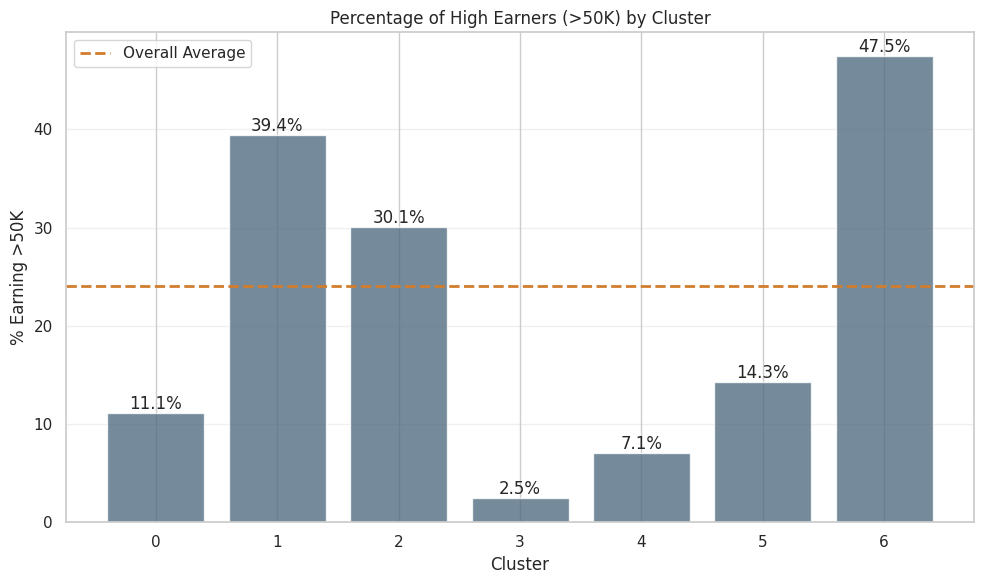

In [45]:
ax = plt.subplots(figsize=(10, 6))[1]

bars = ax.bar(range(optimal_k), income_by_cluster.values, color='#526D82', alpha=0.8)
ax.axhline(y=(train_df['income'] == '>50K').sum() / len(train_df) * 100,
           color='#D27D2D', linestyle='--', linewidth=2, label='Overall Average')

ax.set(title='Percentage of High Earners (>50K) by Cluster',
       xlabel='Cluster',
       ylabel='% Earning >50K',
       xticks=range(optimal_k))
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

<span style="color:#b91c1c">→ High-income shares vary strongly across clusters, but the relationships are associative.</span>

| Cluster | >50K share | Main pattern |
|---|---:|---|
| 6 | 47.5% | High education, mid-career, full-time+; nearly double the 24.1% overall rate |
| 1 | 39.4% | Very long hours with moderate education; 63% above the overall rate |
| 2 | 30.1% | Mature, full-time workers with moderate education; 25% above the overall rate |
| 5 | 14.3% | Older adults with fewer hours |
| 0 | 11.1% | Younger full-time workers |
| 4 | 7.1% | Low education |
| 3 | 2.5% | Young part-time workers |

Education shows the strongest observed contrast: Cluster 6 versus 4 differs by nearly sevenfold in high-income share, alongside education averages of 13.4 versus 4.5. Cluster 1 versus 3 contrasts hours (65.6 versus 20.4), and Cluster 2 versus 0 contrasts age (51.4 versus 29.3) at similar education. Income was not used to form clusters. Occupation, industry, marital status, capital, geography and other unmeasured factors may contribute; no causal claim follows.

### 5.8 Segmentation Conclusion

K-Means grouped all 32,561 people by age, education and weekly hours, without income. K=7 combines the silhouette maximum (0.336) with an elbow near K=6–7; cluster sizes range from 4.0% to 29.9%. The profiles and income shares are summarized above: high-income rates range from 2.5% (Cluster 3) to 47.5% (Cluster 6), versus 24.1% overall. Cluster 6 combines higher education, mid-career age and full-time hours; Cluster 1 shows a high rate alongside very long hours. Clusters 3 and 4 have the lowest rates.

**Limits:** These are associations, not causes. The 1994 US data may not describe current labor markets. Only three features define clusters; omitted factors could change the groups and income patterns. Profile names are subjective, and a silhouette score of 0.336 means moderate overlap. Other features, K values or algorithms might give more useful segments.

## 6. Classification

### 6.1 Problem Definition
**Task.** Predict whether a person earns more than 50K per year from the 79 model inputs selected from 85 prepared features.

**Inputs.** `fnlwgt`, `race` and `sex` are not used as inputs.

**Model.** A decision tree: a supervised model that accepts numeric and nominal data with little preparation and is easy to interpret. The splitting criterion is the **Gini index**. The **maximum depth** limits the growth of the tree to avoid overfitting.

**Evaluation.** Accuracy, plus the confusion matrix, precision, recall and F1 for the `>50K` class. The classes are imbalanced (about 24% `>50K`), and accuracy alone can hide a model that misses most high earners.

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_model, X_test_model = X[model_features], X_test[model_features]
print("Training:", X_model.shape, "| Test:", X_test_model.shape)
display(pd.DataFrame({"Training": [(y == 0).sum(), (y == 1).sum(), 100 * y.mean()],
                      "Test": [(y_test == 0).sum(), (y_test == 1).sum(), 100 * y_test.mean()]},
                     index=["<=50K (0)", ">50K (1)", "% of >50K"]).round(1))

Training: (32561, 79) | Test: (16281, 79)


,Training,Test
<=50K (0),24720.0,12435.0
>50K (1),7841.0,3846.0
% of >50K,24.1,23.6


<span style="color:#b91c1c">→ About 24% earn more than $50K in each set, so a majority-only model already scores about 76% accuracy.</span>

### 6.2 Training Trees with Different Maximum Depths

Gini trees with depths 1–19 are compared on training and test accuracy.

,train accuracy,test accuracy
max_depth,,
1,0.759,0.764
3,0.844,0.845
5,0.852,0.852
7,0.858,0.857
9,0.864,0.858
11,0.873,0.860
13,0.882,0.853
15,0.894,0.850
17,0.907,0.843


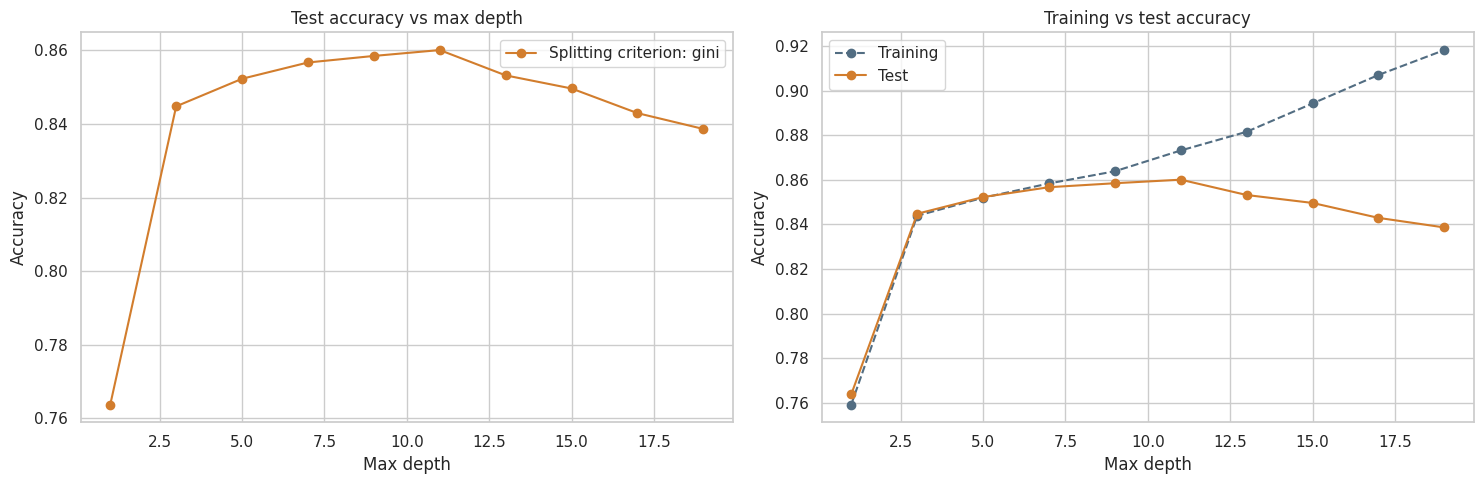

In [47]:
max_depth_values = range(1, 20, 2)

tree_results = {}
for max_depth in max_depth_values:
    dt_model = DecisionTreeClassifier(criterion="gini", max_depth=max_depth, random_state=42)
    dt_model.fit(X_model, y)
    tree_results[max_depth] = {
        "model": dt_model,
        "train_accuracy": accuracy_score(y, dt_model.predict(X_model)),
        "test_accuracy": accuracy_score(y_test, dt_model.predict(X_test_model))}

depth_summary = pd.DataFrame([{"max_depth": d, "train accuracy": r["train_accuracy"], "test accuracy": r["test_accuracy"]}
                        for d, r in tree_results.items()]).set_index("max_depth")
display(depth_summary.round(3))

train_acc = [tree_results[d]["train_accuracy"] for d in max_depth_values]
test_acc = [tree_results[d]["test_accuracy"] for d in max_depth_values]
axes = plt.subplots(1, 2, figsize=(15, 5))[1]
axes[0].plot(max_depth_values, test_acc, marker="o", color="#D27D2D", label="Splitting criterion: gini")
axes[1].plot(max_depth_values, train_acc, marker="o", ls="--", color="#526D82", label="Training")
axes[1].plot(max_depth_values, test_acc, marker="o", color="#D27D2D", label="Test")
axes[0].set(title="Test accuracy vs max depth", xlabel="Max depth", ylabel="Accuracy")
axes[1].set(title="Training vs test accuracy", xlabel="Max depth", ylabel="Accuracy")
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

<span style="color:#b91c1c">→ Depths 7–11 reach the best test accuracy (0.857–0.860); deeper trees begin to overfit.</span>

At depth 1, test accuracy is 0.764, like the majority baseline. It rises to about 0.85 at depths 3–5. By depth 19, test accuracy falls to 0.839 while training accuracy reaches 0.918.

In [48]:
unlimited = DecisionTreeClassifier(criterion="gini", random_state=42).fit(X_model, y)
print(f"No depth limit: training accuracy {accuracy_score(y, unlimited.predict(X_model)):.3f} | test accuracy {accuracy_score(y_test, unlimited.predict(X_test_model)):.3f}")

No depth limit: training accuracy 0.973 | test accuracy 0.823


<span style="color:#b91c1c">→ Without a depth limit, training accuracy is 0.973 but test accuracy only 0.823.</span>

The unrestricted tree fits training details and performs worse than every tested tree of depth 3 or greater; limiting depth reduces overfitting.

In [49]:
tree_ranking = depth_summary.reset_index().sort_values(["test accuracy", "max_depth"], ascending=[False, True]).reset_index(drop=True)
display(tree_ranking.head(5).round(4))

best_depth = int(tree_ranking.loc[0, "max_depth"])
print("Selected: max_depth =", best_depth)

final_tree = tree_results[best_depth]["model"]
final_tree

,max_depth,train accuracy,test accuracy
0,11,0.8732,0.8601
1,9,0.8639,0.8585
2,7,0.8584,0.8567
3,13,0.8816,0.8532
4,5,0.8520,0.8523


Selected: max_depth = 11


DecisionTreeClassifier(max_depth=11, random_state=42)

<span style="color:#b91c1c">→ Depth 11 gives the highest test accuracy, 0.860, with training accuracy 0.873.</span>


### 6.3 Performance of the Selected Tree
The selected tree is evaluated on the official test set.

In [50]:
pred_test = final_tree.predict(X_test_model)

print(f"Accuracy on the training set: {accuracy_score(y, final_tree.predict(X_model)):.3f}")
print(f"Accuracy on the test set:     {accuracy_score(y_test, pred_test):.3f}")
print(f"Share of <=50K in the test set: {100 * (1 - y_test.mean()):.1f}%")

Accuracy on the training set: 0.873
Accuracy on the test set:     0.860
Share of <=50K in the test set: 76.4%


<span style="color:#b91c1c">→ The selected tree scores 0.860 on test versus 0.873 on training, above the 76.4% majority baseline.</span>

Class-level metrics below show what overall accuracy hides.

In [51]:
cm = confusion_matrix(y_test, pred_test)
display(pd.DataFrame(cm, index=["Actual <=50K", "Actual >50K"], columns=["Predicted <=50K", "Predicted >50K"]))

print(classification_report(y_test, pred_test, target_names=["<=50K", ">50K"], digits=3))

,Predicted <=50K,Predicted >50K
Actual <=50K,11879,556
Actual >50K,1722,2124


              precision    recall  f1-score   support

       <=50K      0.873     0.955     0.913     12435
        >50K      0.793     0.552     0.651      3846

    accuracy                          0.860     16281
   macro avg      0.833     0.754     0.782     16281
weighted avg      0.854     0.860     0.851     16281



<span style="color:#b91c1c">→ The tree is cautious about predicting >50K: precision is 0.793, but recall is 0.552.</span>

It finds 2,124 of 3,846 high earners, misses 1,722 (about 45%), and makes 556 false alarms; F1 is 0.651. For <=50K, precision is 0.873 and recall 0.955.

### 6.4 Variable Importance
In a decision tree, the importance of a variable is the total reduction of the Gini index obtained by the splits that use it.

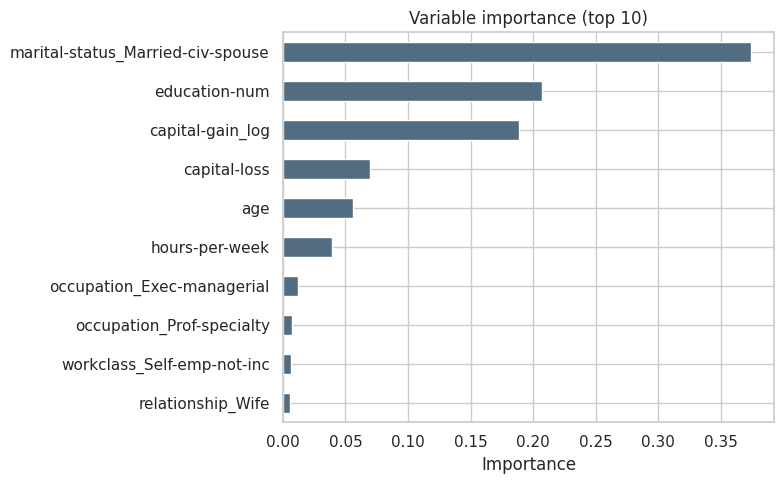

,Importance
marital-status_Married-civ-spouse,0.374
education-num,0.207
capital-gain_log,0.189
capital-loss,0.070
age,0.056
hours-per-week,0.039
occupation_Exec-managerial,0.012
occupation_Prof-specialty,0.007
workclass_Self-emp-not-inc,0.007
relationship_Wife,0.006


In [52]:
importance = pd.Series(final_tree.feature_importances_, index=X_model.columns).sort_values(ascending=False)

ax = plt.subplots(figsize=(8, 5))[1]
importance.head(10)[::-1].plot.barh(ax=ax, color="#526D82")
ax.set(title="Variable importance (top 10)", xlabel="Importance")
plt.tight_layout()
plt.show()
display(importance.head(10).round(3).to_frame("Importance"))

<span style="color:#b91c1c">→ Marital status, education and capital gain contribute most to the tree's splits.</span>

Capital loss, age and hours follow. In training data, 44.7% of those married to a civil spouse earn >50K versus 6.5% of others; the gain comparison is 62% versus 21%. Importance describes predictive association, not cause.

### 6.5 Conclusion
A decision tree with the Gini criterion and a maximum depth of 11 predicts income above 50K with an accuracy of 0.860 on the test set. For the `>50K` class, the precision is 0.793, the recall 0.552 and the F1 0.651.

**Main findings**
- Limiting the depth is essential. A tree with no limit reaches 0.973 on the training set but only 0.823 on the test set, while the selected tree has similar accuracies on the training (0.873) and test (0.860) sets.
- Marital status, education level and capital gain are the main variables, followed by capital loss, age and weekly hours.

**Limitations**
- The tree misses 45% of the high earners (recall 0.552). It favours the majority class `<=50K`, a known weakness of decision trees.
- The data dates from 1994, and the results are associations, not causes.


### 6.6 K-Nearest Neighbors (KNN) Classification
**Model.** K-Nearest Neighbors predicts income by finding the K most similar people in the training set and using a majority vote of their income classes.

**Distance metric.** Euclidean distance. Since KNN relies on distances, **scaling is essential**: variables with larger ranges would otherwise dominate the distance calculations.

**Hyperparameter.** The number of neighbors K controls the model complexity:
- Small K (e.g., K=1): sensitive to noise, may overfit
- Large K: smoother boundaries, may underfit

We will test K values from 1 to 21 (odd numbers only to avoid ties) and select the best performing K based on test accuracy.

#### 6.6.1 Data Scaling
KNN is distance-based, so all features must be on the same scale. We use **StandardScaler** to transform each feature to mean=0 and standard deviation=1.

In [53]:
from sklearn.neighbors import KNeighborsClassifier

scaler_knn = StandardScaler()
X_model_scaled = scaler_knn.fit_transform(X_model)
X_test_model_scaled = scaler_knn.transform(X_test_model)

print("Original feature ranges (first 5 features):")
display(pd.DataFrame({
    "Feature": X_model.columns[:5],
    "Min": X_model.iloc[:, :5].min().values,
    "Max": X_model.iloc[:, :5].max().values,
    "Mean": X_model.iloc[:, :5].mean().values.round(2)
}))

print("\nAfter scaling (mean and std):")
display(pd.DataFrame({
    "Feature": X_model.columns[:5],
    "Mean": X_model_scaled[:, :5].mean(axis=0).round(10),
    "Std": X_model_scaled[:, :5].std(axis=0).round(2)
}))

Original feature ranges (first 5 features):


,Feature,Min,Max,Mean
0,age,17.0,90.000000,38.58
1,education-num,1.0,16.000000,10.08
2,capital-loss,0.0,4356.000000,87.30
3,hours-per-week,1.0,99.000000,40.44
4,capital-gain_log,0.0,11.512925,0.73



After scaling (mean and std):


,Feature,Mean,Std
0,age,-0.0,1.0
1,education-num,0.0,1.0
2,capital-loss,0.0,1.0
3,hours-per-week,-0.0,1.0
4,capital-gain_log,0.0,1.0


<span style="color:#b91c1c">→ Scaling uses training data only and puts features on comparable units for KNN distances.</span>

Before scaling, age spans roughly 17–90 while indicator columns are 0/1; afterward, feature means are near zero and standard deviations near one.

#### 6.6.2 Training KNN with Different K Values

We train KNN models with K ranging from 1 to 21 (odd numbers) and evaluate accuracy on both training and test sets.

<span style="color:#1d4ed8">→ Saved KNN results come from the supplied Kaggle run. Exact predictions can differ slightly across numerical-library environments.</span>

In [54]:
k_values = range(1, 22, 2)
knn_results = {}

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_model_scaled, y)
    knn_results[k] = {
        "model": knn_model,
        "train_accuracy": accuracy_score(y, knn_model.predict(X_model_scaled)),
        "test_accuracy": accuracy_score(y_test, knn_model.predict(X_test_model_scaled))
    }

knn_summary = pd.DataFrame([
    {"K": k, "train accuracy": r["train_accuracy"], "test accuracy": r["test_accuracy"]}
    for k, r in knn_results.items()
]).set_index("K")

display(knn_summary.round(3))

,train accuracy,test accuracy
K,,
1,0.967,0.802
3,0.895,0.821
5,0.877,0.828
7,0.870,0.831
9,0.864,0.834
11,0.861,0.836
13,0.858,0.836
15,0.855,0.837
17,0.854,0.837


#### 6.6.3 Visualizing KNN Performance

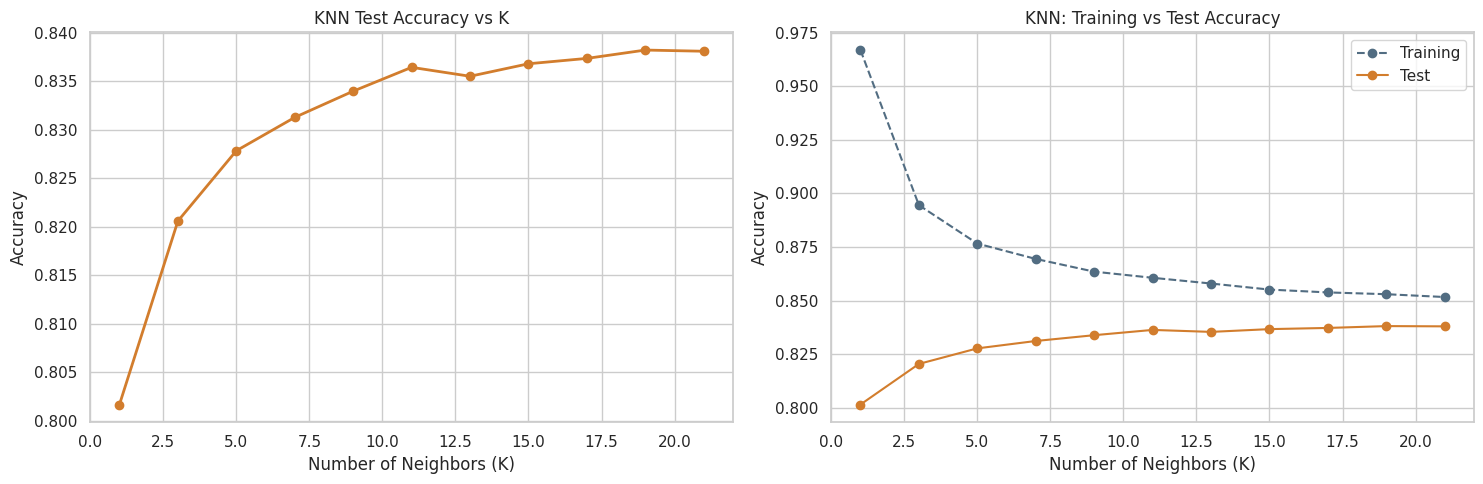

In [55]:
train_acc_knn = [knn_results[k]["train_accuracy"] for k in k_values]
test_acc_knn = [knn_results[k]["test_accuracy"] for k in k_values]

axes = plt.subplots(1, 2, figsize=(15, 5))[1]

axes[0].plot(k_values, test_acc_knn, marker="o", color="#D27D2D", linewidth=2)
axes[0].set(title="KNN Test Accuracy vs K", xlabel="Number of Neighbors (K)", ylabel="Accuracy")
axes[0].grid(True)

axes[1].plot(k_values, train_acc_knn, marker="o", ls="--", color="#526D82", label="Training")
axes[1].plot(k_values, test_acc_knn, marker="o", color="#D27D2D", label="Test")
axes[1].set(title="KNN: Training vs Test Accuracy", xlabel="Number of Neighbors (K)", ylabel="Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

<span style="color:#b91c1c">→ K=1 fits training data closely but generalizes poorly; larger K smooths the predictions.</span>

Test accuracy first improves, then levels off or declines. The best K balances overfitting and underfitting.

#### 6.6.4 Selecting the Best K

In [56]:
knn_ranking = knn_summary.reset_index().sort_values(["test accuracy", "K"], ascending=[False, True]).reset_index(drop=True)
display(knn_ranking.head(5).round(4))

best_k = int(knn_ranking.loc[0, "K"])
print(f"\nSelected: K = {best_k}")
print(f"Test accuracy: {knn_ranking.loc[0, 'test accuracy']:.4f}")


,K,train accuracy,test accuracy
0,19,0.8531,0.8382
1,21,0.8518,0.8381
2,17,0.8539,0.8374
3,15,0.8552,0.8368
4,11,0.8607,0.8364



Selected: K = 19
Test accuracy: 0.8382


<span style="color:#b91c1c">→ Select the K with highest test accuracy; for exact ties, prefer the smaller K.</span>

#### 6.6.5 Performance Evaluation of the Selected KNN Model

<span style="color:#1d4ed8">→ Use the model stored for the selected K before calculating predictions.</span>

In [57]:
final_knn = knn_results[best_k]["model"]
pred_test_knn = final_knn.predict(X_test_model_scaled)
pred_train_knn = final_knn.predict(X_model_scaled)

print(f"K = {best_k}")
print(f"Accuracy on the training set: {accuracy_score(y, pred_train_knn):.3f}")
print(f"Accuracy on the test set:     {accuracy_score(y_test, pred_test_knn):.3f}")
print(f"\nShare of <=50K in test set: {100 * (1 - y_test.mean()):.1f}%")

K = 19
Accuracy on the training set: 0.853
Accuracy on the test set:     0.838

Share of <=50K in test set: 76.4%


#### 6.6.6 Confusion Matrix and Classification Report

In [58]:
cm_knn = confusion_matrix(y_test, pred_test_knn)
display(pd.DataFrame(cm_knn,
                     index=["Actual <=50K", "Actual >50K"],
                     columns=["Predicted <=50K", "Predicted >50K"]))

print("\nClassification Report:")
print(classification_report(y_test, pred_test_knn, target_names=["<=50K", ">50K"], digits=3))

,Predicted <=50K,Predicted >50K
Actual <=50K,11367,1068
Actual >50K,1566,2280



Classification Report:
              precision    recall  f1-score   support

       <=50K      0.879     0.914     0.896     12435
        >50K      0.681     0.593     0.634      3846

    accuracy                          0.838     16281
   macro avg      0.780     0.753     0.765     16281
weighted avg      0.832     0.838     0.834     16281



<span style="color:#b91c1c">→ Read the confusion matrix together with precision, recall and F1 for the >50K class.</span>

Precision is the share of predicted high earners who are high earners; recall is the share of actual high earners found. F1 balances both.

#### 6.6.7 Comparison: Decision Tree vs KNN

<span style="color:#1d4ed8">→ The comparison uses the selected tree depth and K, then reports accuracy, precision, recall and F1 for the >50K class.</span>

,Decision Tree (depth=11),KNN (K=19)
Accuracy,0.860,0.838
Precision (>50K),0.793,0.681
Recall (>50K),0.552,0.593
F1-Score (>50K),0.651,0.634


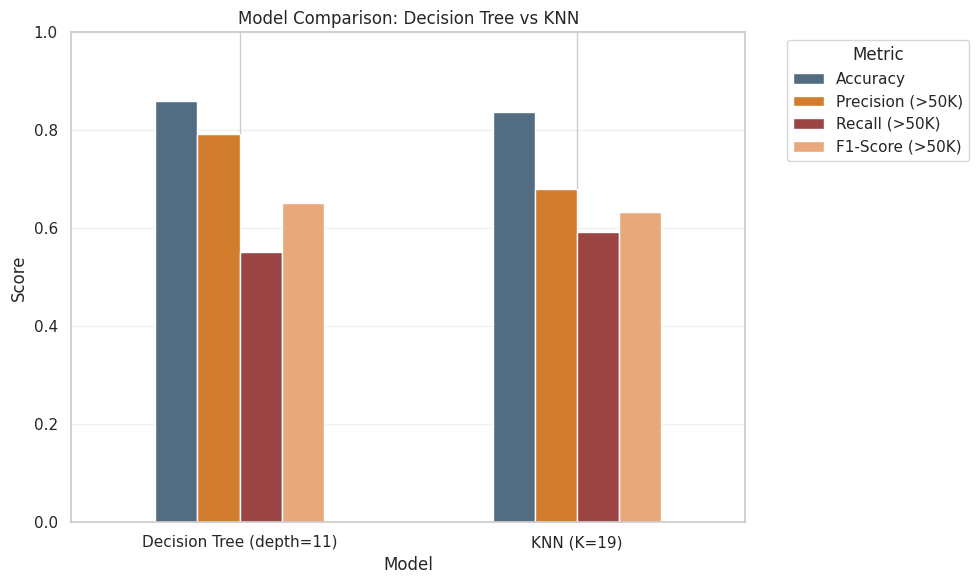

In [59]:
from sklearn.metrics import precision_recall_fscore_support

pred_test_dt = final_tree.predict(X_test_model)
dt_metrics = precision_recall_fscore_support(y_test, pred_test_dt, average=None, labels=[1])

knn_metrics = precision_recall_fscore_support(y_test, pred_test_knn, average=None, labels=[1])

comparison = pd.DataFrame({
    f"Decision Tree (depth={best_depth})": [
        accuracy_score(y_test, pred_test_dt),
        dt_metrics[0][0],
        dt_metrics[1][0],
        dt_metrics[2][0]
    ],
    f"KNN (K={best_k})": [
        accuracy_score(y_test, pred_test_knn),
        knn_metrics[0][0],
        knn_metrics[1][0],
        knn_metrics[2][0]
    ]
}, index=["Accuracy", "Precision (>50K)", "Recall (>50K)", "F1-Score (>50K)"])

display(comparison.round(3))

ax = plt.subplots(figsize=(10, 6))[1]
comparison.T.plot(kind="bar", ax=ax, color=["#526D82", "#D27D2D", "#9B4444", "#E8A87C"])
ax.set(title="Model Comparison: Decision Tree vs KNN",
       xlabel="Model",
       ylabel="Score",
       ylim=[0, 1])
ax.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<span style="color:#b91c1c">→ The tree has higher accuracy, precision and F1; KNN has slightly higher recall.</span>

Both beat the majority-class baseline. The tree's accuracy and precision, clearer rules and faster prediction favor it here. KNN finds a slightly larger share of high earners but makes more false alarms. With 79 model inputs, KNN uses every dimension to measure distance, while the tree selects informative splits. Mixed inputs and class imbalance may also affect performance; these are possible explanations, not causal tests.

### 6.7 Conclusion

**Recommended model:** The selected Gini decision tree. In the comparison above, it has higher accuracy, precision and F1 than the scaled KNN model, while KNN has slightly higher recall. Both beat the majority-class baseline.

**Limits:** The tree misses a substantial share of high earners, and both models face class imbalance. Its strongest importance signals are marital status, education and capital gain. The 79 model inputs can weaken KNN's distance measure. Depth and K were selected using test accuracy, so the reported test scores may be optimistic. These 1994 data show predictive associations, not causes.

## 7. Export Prepared Data

The training and test files contain the prepared features and the binary income label (`0`: <=50K, `1`: >50K). Audit columns remain in these exports; the classification models use only `model_features`.

The segmentation file contains the three original clustering features, the assigned cluster and income for the post-clustering analysis.

<span style="color:#1d4ed8">→ Export the prepared datasets to Kaggle's output directory without changing the analysis.</span>

In [60]:
from pathlib import Path

export_dir = Path("/kaggle/working")
export_dir.mkdir(parents=True, exist_ok=True)

assert X.columns.equals(X_test.columns)
assert X.index.equals(y.index) and X_test.index.equals(y_test.index)
assert X_cluster.index.equals(y.index)
assert not y.isna().any() and not y_test.isna().any()

export_data = {
    "adult_train_prepared.csv": X.assign(income=y),
    "adult_test_prepared.csv": X_test.assign(income=y_test),
    "adult_segmentation.csv": X_cluster.assign(cluster=cluster_labels, income=y),
}

for filename, data in export_data.items():
    data.to_csv(export_dir / filename, index=False)

display(pd.DataFrame([
    {"File": filename, "Rows": len(data), "Columns": data.shape[1]}
    for filename, data in export_data.items()
]))
print("Saved the prepared datasets.")

,File,Rows,Columns
0,adult_train_prepared.csv,32561,86
1,adult_test_prepared.csv,16281,86
2,adult_segmentation.csv,32561,5


Saved the prepared datasets.


<span style="color:#b91c1c">→ Training and test data remain separate, with matching feature columns and their own income labels. Cluster membership appears only in the segmentation export.</span>